# Notebook 32 — Stable Diffusion Uncertainty Heatmaps

This notebook converts the existing Stable Diffusion multi-seed uncertainty outputs into spatial uncertainty heatmaps.

Notebook 27 already generated multiple Stable Diffusion outputs for the same damaged inputs using different random seeds. This notebook does not rerun Stable Diffusion. Instead, it uses those existing seed outputs to visualize where generated restorations vary spatially.

The goal is to support the thesis argument that visual plausibility is not the same as restoration trustworthiness.

The heatmaps are interpreted as seed-based spatial variability diagnostics, not calibrated model-confidence estimates.

Main outputs:

- uncertainty heatmap summaries by case,
- uncertainty heatmap summaries by mask type,
- uncertainty heatmap summaries by painting category,
- selected uncertainty heatmap visual figures,
- compact uncertainty heatmap report.

The analysis includes:

- full-image seed variability,
- masked-region seed variability,
- mask-bounding-box seed variability,
- boundary-ring seed variability,
- outside-mask seed variability.

In [1]:
from pathlib import Path, PureWindowsPath
import json
import math
from html import escape

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import ndimage as ndi

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

print("Notebook 32 imports ready.")

Notebook 32 imports ready.


In [2]:
NOTEBOOK_NAME = "32_uncertainty_heatmaps_cleaned"

REPO_FOLDER_NAME_CANDIDATES = [
    "painting-restoration-eval",
    "painting_restoration_eval",
]


def find_project_root(
    start_path: Path | None = None,
    repo_folder_name_candidates: list[str] | None = None,
) -> Path:
    """
    Find the project root from the current working directory.

    Supports both historical/local folder names:
    - painting-restoration-eval
    - painting_restoration_eval
    """
    if repo_folder_name_candidates is None:
        repo_folder_name_candidates = REPO_FOLDER_NAME_CANDIDATES

    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for parent in [start_path] + list(start_path.parents):
        if parent.name in repo_folder_name_candidates:
            return parent

        if (
            (parent / ".git").exists()
            and (parent / "notebooks").exists()
            and (parent / "data").exists()
            and (parent / "outputs").exists()
        ):
            return parent

        if (
            (parent / "notebooks").exists()
            and (parent / "data").exists()
            and (parent / "outputs").exists()
        ):
            return parent

    raise RuntimeError(
        f"Could not find project root from {start_path}. "
        f"Tried folder names: {repo_folder_name_candidates}"
    )


PROJECT_ROOT = find_project_root()
REPO_FOLDER_NAME = PROJECT_ROOT.name

data_dir = PROJECT_ROOT / "data"
processed_dir = data_dir / "processed"
processed_metadata_dir = processed_dir / "metadata"

outputs_dir = PROJECT_ROOT / "outputs"
metrics_dir = outputs_dir / "metrics"
reports_dir = outputs_dir / "reports"

figures_dir = outputs_dir / "figures"
uncertainty_figures_dir = figures_dir / "uncertainty_heatmaps"
uncertainty_all_cases_dir = uncertainty_figures_dir / "all_cases"
uncertainty_selected_cases_dir = uncertainty_figures_dir / "selected_cases"
uncertainty_heatmap_images_dir = uncertainty_figures_dir / "heatmap_images"
uncertainty_overlay_images_dir = uncertainty_figures_dir / "overlay_images"

for directory in [
    metrics_dir,
    reports_dir,
    uncertainty_figures_dir,
    uncertainty_all_cases_dir,
    uncertainty_selected_cases_dir,
    uncertainty_heatmap_images_dir,
    uncertainty_overlay_images_dir,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Repository folder name:", REPO_FOLDER_NAME)
print("Uncertainty figure directory:", uncertainty_figures_dir)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Repository folder name: painting-restoration-eval
Uncertainty figure directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps


In [3]:
input_paths = {
    "uncertainty_generations": metrics_dir / "stable_diffusion_uncertainty_generations_50.csv",
    "uncertainty_combined_summary": metrics_dir / "stable_diffusion_uncertainty_combined_summary_by_case_50.csv",
    "uncertainty_vs_refined_performance": metrics_dir / "stable_diffusion_uncertainty_vs_refined_performance_50.csv",
    "uncertainty_performance_quadrants": metrics_dir / "stable_diffusion_uncertainty_performance_quadrants_50.csv",
    "refined_comparison": metrics_dir / "comparison_unified_refined_opencv_lama_stable_diffusion_50.csv",
    "processed_clean_metadata": processed_metadata_dir / "metadata_processed_clean.csv",
    "damaged_metadata": processed_metadata_dir / "metadata_damaged_images.csv",
}

heatmap_output_paths = {
    "heatmap_manifest": metrics_dir / "stable_diffusion_uncertainty_heatmap_manifest_50.csv",
    "heatmap_summary_by_case": metrics_dir / "stable_diffusion_uncertainty_heatmap_summary_by_case_50.csv",
    "heatmap_summary_by_mask_type": metrics_dir / "stable_diffusion_uncertainty_heatmap_summary_by_mask_type_50.csv",
    "heatmap_summary_by_category": metrics_dir / "stable_diffusion_uncertainty_heatmap_summary_by_category_50.csv",
    "heatmap_selected_cases": metrics_dir / "stable_diffusion_uncertainty_heatmap_selected_cases_50.csv",
    "heatmap_performance_linkage": metrics_dir / "stable_diffusion_uncertainty_heatmap_vs_refined_performance_50.csv",
    "heatmap_report": reports_dir / "stable_diffusion_uncertainty_heatmap_report_50.html",
}

heatmap_figure_paths = {
    "masked_uncertainty_by_mask_type": uncertainty_figures_dir / "masked_uncertainty_by_mask_type.png",
    "bbox_uncertainty_by_mask_type": uncertainty_figures_dir / "bbox_uncertainty_by_mask_type.png",
    "boundary_uncertainty_by_mask_type": uncertainty_figures_dir / "boundary_uncertainty_by_mask_type.png",
    "masked_uncertainty_by_category": uncertainty_figures_dir / "masked_uncertainty_by_category.png",
    "boundary_uncertainty_by_category": uncertainty_figures_dir / "boundary_uncertainty_by_category.png",
    "uncertainty_vs_reference_performance": uncertainty_figures_dir / "uncertainty_vs_reference_performance.png",
}

print("Input paths:")
for name, path in input_paths.items():
    print(f"- {name}: {path}")

print("\nOutput paths:")
for name, path in heatmap_output_paths.items():
    print(f"- {name}: {path}")

print("\nFigure paths:")
for name, path in heatmap_figure_paths.items():
    print(f"- {name}: {path}")

Input paths:
- uncertainty_generations: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_generations_50.csv
- uncertainty_combined_summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_combined_summary_by_case_50.csv
- uncertainty_vs_refined_performance: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_vs_refined_performance_50.csv
- uncertainty_performance_quadrants: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_performance_quadrants_50.csv
- refined_comparison: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_unified_refined_opencv_lama_stable_diffusion_50.csv
- processed_clean_metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
- damaged_metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata

In [4]:
def get_repo_folder_candidates() -> list[str]:
    candidates = [
        "painting-restoration-eval",
        "painting_restoration_eval",
        REPO_FOLDER_NAME,
    ]

    return list(dict.fromkeys(candidates))


def to_project_relative_path(path_value: str | Path | None) -> str | None:
    if path_value is None:
        return None

    try:
        if pd.isna(path_value):
            return None
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        return None

    normalized_text = path_text.replace("\\", "/")

    for repo_folder_name in get_repo_folder_candidates():
        marker = f"/{repo_folder_name}/"

        if marker in normalized_text:
            return normalized_text.split(marker, 1)[1]

        if normalized_text.startswith(f"{repo_folder_name}/"):
            return normalized_text.split(f"{repo_folder_name}/", 1)[1]

    path = Path(normalized_text)

    if not path.is_absolute():
        return path.as_posix()

    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        pass

    windows_path = PureWindowsPath(path_text)

    for repo_folder_name in get_repo_folder_candidates():
        if repo_folder_name in windows_path.parts:
            repo_index = windows_path.parts.index(repo_folder_name)
            relative_parts = windows_path.parts[repo_index + 1:]
            return Path(*relative_parts).as_posix()

    return normalized_text


def resolve_project_path(path_value: str | Path | None) -> Path | None:
    """
    Resolve stored project paths robustly across machines.

    Handles:
    - relative project paths,
    - absolute paths from the current machine,
    - old absolute paths from another clone location,
    - old Windows D:/... paths stored in CSV metadata,
    - both hyphen and underscore repo folder names.
    """
    if path_value is None:
        return None

    try:
        if pd.isna(path_value):
            return None
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        return None

    normalized_text = path_text.replace("\\", "/")

    for repo_folder_name in get_repo_folder_candidates():
        marker = f"/{repo_folder_name}/"

        if marker in normalized_text:
            relative_part = normalized_text.split(marker, 1)[1]
            return PROJECT_ROOT / relative_part

        if normalized_text.startswith(f"{repo_folder_name}/"):
            relative_part = normalized_text.split(f"{repo_folder_name}/", 1)[1]
            return PROJECT_ROOT / relative_part

    windows_path = PureWindowsPath(path_text)

    for repo_folder_name in get_repo_folder_candidates():
        if repo_folder_name in windows_path.parts:
            repo_index = windows_path.parts.index(repo_folder_name)
            relative_parts = windows_path.parts[repo_index + 1:]
            return PROJECT_ROOT.joinpath(*relative_parts)

    path = Path(path_text)

    if path.is_absolute():
        if path.exists():
            return path

        for repo_folder_name in get_repo_folder_candidates():
            if repo_folder_name in path.parts:
                repo_index = path.parts.index(repo_folder_name)
                relative_parts = path.parts[repo_index + 1:]
                return PROJECT_ROOT.joinpath(*relative_parts)

        return path

    return PROJECT_ROOT / path


def find_first_existing_column(
    df: pd.DataFrame,
    candidates: list[str],
) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column

    return None


print("Path helper functions ready.")

Path helper functions ready.


In [5]:
def load_rgb_image(path: str | Path) -> np.ndarray:
    resolved_path = resolve_project_path(path)

    if resolved_path is None:
        raise ValueError("Cannot load image from empty path.")

    if not resolved_path.exists():
        raise FileNotFoundError(f"Image not found: {resolved_path}")

    image = Image.open(resolved_path).convert("RGB")
    return np.asarray(image)


def load_mask_image(path: str | Path) -> np.ndarray:
    resolved_path = resolve_project_path(path)

    if resolved_path is None:
        raise ValueError("Cannot load mask from empty path.")

    if not resolved_path.exists():
        raise FileNotFoundError(f"Mask not found: {resolved_path}")

    mask = Image.open(resolved_path).convert("L")
    mask_array = np.asarray(mask)

    return mask_array > 0


def save_rgb_image(image_array: np.ndarray, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    clipped = np.clip(image_array, 0, 255).astype(np.uint8)
    Image.fromarray(clipped).save(output_path)


def save_grayscale_heatmap(
    heatmap: np.ndarray,
    output_path: Path,
) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    heatmap_clean = np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)
    heatmap_min = float(np.min(heatmap_clean))
    heatmap_max = float(np.max(heatmap_clean))

    if heatmap_max > heatmap_min:
        normalized = (heatmap_clean - heatmap_min) / (heatmap_max - heatmap_min)
    else:
        normalized = np.zeros_like(heatmap_clean)

    image_uint8 = (normalized * 255).clip(0, 255).astype(np.uint8)
    Image.fromarray(image_uint8).save(output_path)


def ensure_same_hw(*arrays: np.ndarray) -> None:
    shapes = [array.shape[:2] for array in arrays]

    if len(set(shapes)) != 1:
        raise ValueError(f"Image/mask shape mismatch: {shapes}")


def get_mask_bbox(
    mask_array: np.ndarray,
    margin: int = 16,
) -> tuple[int, int, int, int]:
    y_indices, x_indices = np.where(mask_array)

    if len(x_indices) == 0 or len(y_indices) == 0:
        raise ValueError("Cannot compute bounding box for empty mask.")

    height, width = mask_array.shape[:2]

    x_min = max(int(x_indices.min()) - margin, 0)
    x_max = min(int(x_indices.max()) + margin + 1, width)

    y_min = max(int(y_indices.min()) - margin, 0)
    y_max = min(int(y_indices.max()) + margin + 1, height)

    return x_min, y_min, x_max, y_max


def crop_to_bbox(
    array: np.ndarray,
    bbox: tuple[int, int, int, int],
) -> np.ndarray:
    x_min, y_min, x_max, y_max = bbox
    return array[y_min:y_max, x_min:x_max]


def create_boundary_ring(
    mask_array: np.ndarray,
    dilation_iterations: int = 8,
) -> np.ndarray:
    """
    Create a ring around the inpaint mask boundary.

    The ring excludes the original mask and captures nearby context.
    """
    if dilation_iterations <= 0:
        raise ValueError("dilation_iterations must be positive.")

    structure = np.ones((3, 3), dtype=bool)

    dilated_mask = ndi.binary_dilation(
        mask_array,
        structure=structure,
        iterations=dilation_iterations,
    )

    boundary_ring = np.logical_and(dilated_mask, ~mask_array)

    return boundary_ring


def create_heatmap_overlay(
    base_image: np.ndarray,
    heatmap: np.ndarray,
    alpha: float = 0.45,
    cmap_name: str = "magma",
) -> np.ndarray:
    """
    Create an RGB overlay image from a base image and normalized heatmap.
    """
    base_float = base_image.astype(np.float32) / 255.0

    heatmap_clean = np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)
    heatmap_min = float(np.min(heatmap_clean))
    heatmap_max = float(np.max(heatmap_clean))

    if heatmap_max > heatmap_min:
        normalized_heatmap = (heatmap_clean - heatmap_min) / (heatmap_max - heatmap_min)
    else:
        normalized_heatmap = np.zeros_like(heatmap_clean)

    cmap = plt.get_cmap(cmap_name)
    colored_heatmap = cmap(normalized_heatmap)[..., :3]

    overlay = (1.0 - alpha) * base_float + alpha * colored_heatmap
    overlay_uint8 = (overlay * 255).clip(0, 255).astype(np.uint8)

    return overlay_uint8


print("Image helper functions ready.")

Image helper functions ready.


In [6]:
missing_inputs = [
    path
    for path in input_paths.values()
    if not path.exists()
]

if missing_inputs:
    for path in missing_inputs:
        print("Missing input:", path)

    raise FileNotFoundError("One or more required Notebook 32 input files are missing.")

uncertainty_generations_df = pd.read_csv(input_paths["uncertainty_generations"])
uncertainty_combined_summary_df = pd.read_csv(input_paths["uncertainty_combined_summary"])
uncertainty_vs_refined_df = pd.read_csv(input_paths["uncertainty_vs_refined_performance"])
uncertainty_quadrants_df = pd.read_csv(input_paths["uncertainty_performance_quadrants"])
refined_comparison_df = pd.read_csv(input_paths["refined_comparison"])
processed_clean_df = pd.read_csv(input_paths["processed_clean_metadata"])
damaged_metadata_df = pd.read_csv(input_paths["damaged_metadata"])

print("Loaded input dataframes:")
print("uncertainty_generations_df:", uncertainty_generations_df.shape)
print("uncertainty_combined_summary_df:", uncertainty_combined_summary_df.shape)
print("uncertainty_vs_refined_df:", uncertainty_vs_refined_df.shape)
print("uncertainty_quadrants_df:", uncertainty_quadrants_df.shape)
print("refined_comparison_df:", refined_comparison_df.shape)
print("processed_clean_df:", processed_clean_df.shape)
print("damaged_metadata_df:", damaged_metadata_df.shape)

print("\nUncertainty generations columns:")
display(pd.DataFrame({"column": uncertainty_generations_df.columns}))

Loaded input dataframes:
uncertainty_generations_df: (160, 155)
uncertainty_combined_summary_df: (40, 55)
uncertainty_vs_refined_df: (40, 75)
uncertainty_quadrants_df: (4, 7)
refined_comparison_df: (200, 40)
processed_clean_df: (50, 43)
damaged_metadata_df: (250, 19)

Uncertainty generations columns:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,clean_filename
...,...
150,stable_diffusion_uncertainty_num_inference_steps
151,stable_diffusion_uncertainty_guidance_scale
152,stable_diffusion_uncertainty_inference_size
153,stable_diffusion_uncertainty_output_size


In [7]:
print("Uncertainty generation dataframe shape:", uncertainty_generations_df.shape)

print("\nColumns:")
for column in uncertainty_generations_df.columns:
    print("-", column)

print("\nCandidate ID column diagnostics:")

candidate_id_columns = [
    column
    for column in uncertainty_generations_df.columns
    if any(token in column.lower() for token in ["case", "id", "mask", "painting"])
]

diagnostics = []

for column in candidate_id_columns:
    unique_count = uncertainty_generations_df[column].nunique(dropna=True)
    null_count = uncertainty_generations_df[column].isna().sum()

    diagnostics.append(
        {
            "column": column,
            "unique_count": unique_count,
            "null_count": null_count,
            "example_values": uncertainty_generations_df[column].dropna().astype(str).head(3).tolist(),
        }
    )

candidate_diagnostics_df = pd.DataFrame(diagnostics).sort_values(
    ["unique_count", "column"],
    ascending=[True, True],
)

display(candidate_diagnostics_df)

print("\nSeed columns:")
for column in uncertainty_generations_df.columns:
    if "seed" in column.lower():
        print(column, "unique:", sorted(uncertainty_generations_df[column].dropna().unique()))

Uncertainty generation dataframe shape: (160, 155)

Columns:
- case_id
- painting_id
- mask_id
- mask_type
- clean_filename
- clean_path
- mask_filename
- mask_path
- damaged_filename
- damaged_path
- damage_fill_strategy
- damage_fill_r
- damage_fill_g
- damage_fill_b
- damaged_area_pixels
- damaged_area_percentage_content
- damaged_area_percentage_full
- status
- issue
- model_name
- restoration_method
- hf_model_id
- inference_mode
- restored_filename
- restored_path
- prompt
- negative_prompt
- seed
- num_inference_steps
- guidance_scale
- inference_size
- device
- case_runtime_seconds
- restored_width
- restored_height
- restored_mode
- category
- title
- uncertainty_selection_role
- mean_sd_metric_wins
- total_sd_metric_wins
- sd_overall_wins
- sd_zero_metric_win_cases
- disagreement_cases
- strength_score
- weakness_score
- overall_metric_vote
- stable_diffusion_inpainting_metric_wins
- mixed_metric_outcome
- stable_diffusion_inpainting_mse_improvement
- winner_mse_improvement
-

,column,unique_count,null_count,example_values
7,guidance_scale,1,0,"[7.5, 7.5, 7.5]"
6,hf_model_id,1,0,"[runwayml/stable-diffusion-inpainting, runwaym..."
9,restored_width,1,0,"[768, 768, 768]"
30,stable_diffusion_guidance_scale,1,0,"[7.5, 7.5, 7.5]"
29,stable_diffusion_hf_model_id,1,0,"[runwayml/stable-diffusion-inpainting, runwaym..."
32,stable_diffusion_restored_width,1,0,"[768, 768, 768]"
43,stable_diffusion_uncertainty_guidance_scale,1,0,"[7.5, 7.5, 7.5]"
42,stable_diffusion_uncertainty_model_id,1,0,"[runwayml/stable-diffusion-inpainting, runwaym..."
20,uncertainty_guidance_scale,1,0,"[7.5, 7.5, 7.5]"
19,uncertainty_model_id,1,0,"[runwayml/stable-diffusion-inpainting, runwaym..."



Seed columns:
seed unique: [2026]
uncertainty_num_seeds unique: [4]
uncertainty_seeds unique: ['2026,2027,2028,2029']
uncertainty_seed unique: [2026, 2027, 2028, 2029]
stable_diffusion_seed unique: [2026, 2027, 2028, 2029]
stable_diffusion_uncertainty_num_seeds unique: [4]
stable_diffusion_uncertainty_seeds unique: ['2026,2027,2028,2029']
stable_diffusion_uncertainty_seed unique: [2026, 2027, 2028, 2029]


In [8]:
expected_generation_rows = 160
expected_case_count = 40
expected_seed_count = 4
expected_seeds = {2026, 2027, 2028, 2029}

required_generation_columns = [
    "original_case_id",
    "uncertainty_generation_id",
    "uncertainty_seed",
    "uncertainty_actual_restored_path",
    "generation_status",
    "generation_output_exists",
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "category",
    "clean_path",
    "damaged_path",
    "mask_path",
]

missing_generation_columns = [
    column
    for column in required_generation_columns
    if column not in uncertainty_generations_df.columns
]

if missing_generation_columns:
    print("Available uncertainty generation columns:")
    for column in uncertainty_generations_df.columns:
        print("-", column)

    raise ValueError(
        f"Uncertainty generation metadata missing expected Notebook 27 columns: "
        f"{missing_generation_columns}"
    )

# Notebook 27 may contain resume duplicates before its cleanup logic.
# Keep the latest row per uncertainty_generation_id when timestamp exists.
generation_sort_column = None

for candidate in ["generation_completed_at", "generation_elapsed_seconds"]:
    if candidate in uncertainty_generations_df.columns:
        generation_sort_column = candidate
        break

clean_generation_df = uncertainty_generations_df.copy()

if generation_sort_column is not None:
    clean_generation_df = (
        clean_generation_df
        .sort_values(generation_sort_column)
        .drop_duplicates(subset=["uncertainty_generation_id"], keep="last")
        .reset_index(drop=True)
    )
else:
    clean_generation_df = (
        clean_generation_df
        .drop_duplicates(subset=["uncertainty_generation_id"], keep="last")
        .reset_index(drop=True)
    )

if len(clean_generation_df) != expected_generation_rows:
    raise ValueError(
        f"Expected {expected_generation_rows} unique uncertainty generation rows, "
        f"found {len(clean_generation_df)}."
    )

if clean_generation_df["uncertainty_generation_id"].duplicated().any():
    duplicated_generation_ids = clean_generation_df[
        clean_generation_df["uncertainty_generation_id"].duplicated(keep=False)
    ]

    display(duplicated_generation_ids)

    raise ValueError("Duplicate uncertainty_generation_id rows remain after cleanup.")

if (clean_generation_df["generation_status"] != "ok").any():
    failed_generation_df = clean_generation_df[
        clean_generation_df["generation_status"] != "ok"
    ]

    display(
        failed_generation_df[
            [
                "original_case_id",
                "uncertainty_seed",
                "generation_status",
                "generation_error_message",
            ]
        ]
    )

    raise ValueError("Some uncertainty generations have non-ok status.")

if not clean_generation_df["generation_output_exists"].astype(bool).all():
    missing_output_metadata_df = clean_generation_df[
        ~clean_generation_df["generation_output_exists"].astype(bool)
    ]

    display(
        missing_output_metadata_df[
            [
                "original_case_id",
                "uncertainty_seed",
                "uncertainty_actual_restored_path",
                "generation_output_exists",
            ]
        ]
    )

    raise FileNotFoundError("Some uncertainty generation outputs are marked missing.")

observed_seeds = set(clean_generation_df["uncertainty_seed"].astype(int).unique())

if observed_seeds != expected_seeds:
    raise ValueError(
        f"Expected uncertainty seeds {sorted(expected_seeds)}, "
        f"found {sorted(observed_seeds)}."
    )

case_seed_counts = (
    clean_generation_df
    .groupby("original_case_id")["uncertainty_seed"]
    .nunique()
    .reset_index(name="unique_seed_count")
)

if len(case_seed_counts) != expected_case_count:
    raise ValueError(
        f"Expected {expected_case_count} uncertainty cases, "
        f"found {len(case_seed_counts)}."
    )

unexpected_seed_counts = case_seed_counts[
    case_seed_counts["unique_seed_count"] != expected_seed_count
]

if not unexpected_seed_counts.empty:
    print("Unexpected seed-count cases:")
    display(unexpected_seed_counts)

    print("Seed count distribution:")
    display(
        case_seed_counts["unique_seed_count"]
        .value_counts()
        .sort_index()
        .rename_axis("unique_seed_count")
        .reset_index(name="case_count")
    )

    raise ValueError("Some uncertainty cases do not have exactly 4 seeds.")

case_seed_duplicates = clean_generation_df.duplicated(
    subset=["original_case_id", "uncertainty_seed"],
    keep=False,
)

if case_seed_duplicates.any():
    duplicated_case_seed_df = clean_generation_df.loc[
        case_seed_duplicates,
        [
            "original_case_id",
            "uncertainty_seed",
            "uncertainty_generation_id",
            "uncertainty_actual_restored_path",
        ],
    ].sort_values(["original_case_id", "uncertainty_seed"])

    display(duplicated_case_seed_df)

    raise ValueError("Duplicate original_case_id/uncertainty_seed rows found.")

standardized_generations_df = pd.DataFrame(
    {
        # Keep Notebook 32's working case_id equal to the original damaged case.
        # Notebook 27's `case_id` is seed-specific in some generation contexts,
        # while `original_case_id` is the stable 40-case key.
        "case_id": clean_generation_df["original_case_id"].astype(str),
        "uncertainty_generation_id": clean_generation_df["uncertainty_generation_id"].astype(str),
        "painting_id": clean_generation_df["painting_id"].astype(str),
        "mask_id": clean_generation_df["mask_id"].astype(str),
        "mask_type": clean_generation_df["mask_type"].astype(str),
        "category": clean_generation_df["category"].astype(str),
        "seed": clean_generation_df["uncertainty_seed"].astype(int),
        "generated_image_path": clean_generation_df["uncertainty_actual_restored_path"],
        "planned_generated_image_path": clean_generation_df["uncertainty_restored_path"]
        if "uncertainty_restored_path" in clean_generation_df.columns
        else clean_generation_df["uncertainty_actual_restored_path"],
        "clean_image_path": clean_generation_df["clean_path"],
        "damaged_image_path": clean_generation_df["damaged_path"],
        "mask_path": clean_generation_df["mask_path"],
    }
)

optional_columns_to_copy = [
    "title",
    "uncertainty_selection_role",
    "mean_sd_metric_wins",
    "total_sd_metric_wins",
    "sd_overall_wins",
    "sd_zero_metric_win_cases",
    "disagreement_cases",
    "strength_score",
    "weakness_score",
    "overall_metric_vote",
    "stable_diffusion_inpainting_metric_wins",
    "mixed_metric_outcome",
    "generation_elapsed_seconds",
    "generation_completed_at",
]

for column in optional_columns_to_copy:
    if column in clean_generation_df.columns:
        standardized_generations_df[column] = clean_generation_df[column]

required_standardized_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "category",
    "seed",
    "generated_image_path",
    "clean_image_path",
    "damaged_image_path",
    "mask_path",
]

null_required_counts = standardized_generations_df[
    required_standardized_columns
].isna().sum()

if (null_required_counts > 0).any():
    print("Null counts in required standardized columns:")
    display(null_required_counts)

    display(
        standardized_generations_df[
            standardized_generations_df[required_standardized_columns].isna().any(axis=1)
        ].head(20)
    )

    raise ValueError("Required standardized generation metadata contains null values.")

# Validate all generated image paths, not just a sample.
missing_generated_files = []

for raw_path in standardized_generations_df["generated_image_path"]:
    resolved_path = resolve_project_path(raw_path)

    if resolved_path is None or not resolved_path.exists():
        missing_generated_files.append((raw_path, resolved_path))

if missing_generated_files:
    print("Missing generated files:")
    for raw_path, resolved_path in missing_generated_files[:20]:
        print(raw_path, "=>", resolved_path)

    raise FileNotFoundError(
        f"{len(missing_generated_files)} generated image files could not be resolved."
    )

# Validate one representative clean/damaged/mask path per case.
case_reference_df = (
    standardized_generations_df
    .sort_values(["case_id", "seed"])
    .drop_duplicates(subset=["case_id"])
    .reset_index(drop=True)
)

missing_reference_files = []

for _, row in case_reference_df.iterrows():
    for label, column in [
        ("clean", "clean_image_path"),
        ("damaged", "damaged_image_path"),
        ("mask", "mask_path"),
    ]:
        resolved_path = resolve_project_path(row[column])

        if resolved_path is None or not resolved_path.exists():
            missing_reference_files.append(
                {
                    "case_id": row["case_id"],
                    "label": label,
                    "raw_path": row[column],
                    "resolved_path": resolved_path,
                }
            )

if missing_reference_files:
    print("Missing reference files:")
    display(pd.DataFrame(missing_reference_files).head(20))

    raise FileNotFoundError(
        f"{len(missing_reference_files)} clean/damaged/mask files could not be resolved."
    )

print("Standardized uncertainty generation metadata ready.")
print("Rows:", len(standardized_generations_df))
print("Unique cases:", standardized_generations_df["case_id"].nunique())
print("Unique seeds:", sorted(standardized_generations_df["seed"].unique()))

print("\nSeed count distribution:")
display(
    case_seed_counts["unique_seed_count"]
    .value_counts()
    .sort_index()
    .rename_axis("unique_seed_count")
    .reset_index(name="case_count")
)

print("\nCases by category:")
display(
    case_reference_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="cases")
)

print("\nCases by mask type:")
display(
    case_reference_df["mask_type"]
    .value_counts()
    .rename_axis("mask_type")
    .reset_index(name="cases")
)

print("\nSample resolved generated image paths:")
for raw_path in standardized_generations_df["generated_image_path"].head(5):
    resolved_path = resolve_project_path(raw_path)
    print(raw_path, "=>", resolved_path, "| exists:", resolved_path.exists())

display(standardized_generations_df.head())

Standardized uncertainty generation metadata ready.
Rows: 160
Unique cases: 40
Unique seeds: [2026, 2027, 2028, 2029]

Seed count distribution:


,unique_seed_count,case_count
0,4,40



Cases by category:


,category,cases
0,portrait_figure,8
1,landscape_natural,8
2,architecture_structured,8
3,abstraction_surrealism,8
4,high_texture_brushwork,8



Cases by mask type:


,mask_type,cases
0,loss_large,10
1,loss_small,10
2,mixed_damage,10
3,scratch_thin,10



Sample resolved generated image paths:
data/processed/restored/stable_diffusion_inpainting_uncertainty/p031_loss_large_seed_2026_restored_stable_diffusion_inpainting.png => D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting_uncertainty\p031_loss_large_seed_2026_restored_stable_diffusion_inpainting.png | exists: True
data/processed/restored/stable_diffusion_inpainting_uncertainty/p031_loss_large_seed_2027_restored_stable_diffusion_inpainting.png => D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting_uncertainty\p031_loss_large_seed_2027_restored_stable_diffusion_inpainting.png | exists: True
data/processed/restored/stable_diffusion_inpainting_uncertainty/p031_loss_large_seed_2028_restored_stable_diffusion_inpainting.png => D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting_uncertainty\p031_loss_large_seed_2028_restored_stable_diffusion_inpaintin

,case_id,uncertainty_generation_id,painting_id,mask_id,mask_type,category,seed,generated_image_path,planned_generated_image_path,clean_image_path,damaged_image_path,mask_path,title,uncertainty_selection_role,mean_sd_metric_wins,total_sd_metric_wins,sd_overall_wins,sd_zero_metric_win_cases,disagreement_cases,strength_score,weakness_score,overall_metric_vote,stable_diffusion_inpainting_metric_wins,mixed_metric_outcome,generation_elapsed_seconds,generation_completed_at
0,p031_loss_large,p031_loss_large_seed_2026,p031,p031_loss_large,loss_large,abstraction_surrealism,2026,data/processed/restored/stable_diffusion_inpai...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,Improvisation No. 30 (Cannons),relatively_weak_or_disagreement_prone_stable_d...,0.0,0,0,4,3,-1.0,7.0,lama,0,True,9.586274,2026-07-06 12:00:05
1,p031_loss_large,p031_loss_large_seed_2027,p031,p031_loss_large,loss_large,abstraction_surrealism,2027,data/processed/restored/stable_diffusion_inpai...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,Improvisation No. 30 (Cannons),relatively_weak_or_disagreement_prone_stable_d...,0.0,0,0,4,3,-1.0,7.0,lama,0,True,7.461976,2026-07-06 12:00:13
2,p031_loss_large,p031_loss_large_seed_2028,p031,p031_loss_large,loss_large,abstraction_surrealism,2028,data/processed/restored/stable_diffusion_inpai...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,Improvisation No. 30 (Cannons),relatively_weak_or_disagreement_prone_stable_d...,0.0,0,0,4,3,-1.0,7.0,lama,0,True,7.518776,2026-07-06 12:00:20
3,p031_loss_large,p031_loss_large_seed_2029,p031,p031_loss_large,loss_large,abstraction_surrealism,2029,data/processed/restored/stable_diffusion_inpai...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,Improvisation No. 30 (Cannons),relatively_weak_or_disagreement_prone_stable_d...,0.0,0,0,4,3,-1.0,7.0,lama,0,True,7.306307,2026-07-06 12:00:28
4,p031_loss_small,p031_loss_small_seed_2026,p031,p031_loss_small,loss_small,abstraction_surrealism,2026,data/processed/restored/stable_diffusion_inpai...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,Improvisation No. 30 (Cannons),relatively_weak_or_disagreement_prone_stable_d...,0.0,0,0,4,3,-1.0,7.0,lama,0,False,7.511533,2026-07-06 12:00:35


In [9]:
HEATMAP_BBOX_MARGIN = 16
BOUNDARY_DILATION_ITERATIONS = 8
HEATMAP_EPSILON = 1e-8


def summarize_heatmap_region(
    heatmap: np.ndarray,
    region_mask: np.ndarray,
    prefix: str,
) -> dict:
    """
    Summarize heatmap values over a boolean region mask.
    """
    if region_mask.shape != heatmap.shape:
        raise ValueError(
            f"Region mask shape {region_mask.shape} does not match heatmap shape {heatmap.shape}."
        )

    values = heatmap[region_mask]

    if values.size == 0:
        return {
            f"{prefix}_pixel_count": 0,
            f"{prefix}_mean_uncertainty": np.nan,
            f"{prefix}_median_uncertainty": np.nan,
            f"{prefix}_std_uncertainty": np.nan,
            f"{prefix}_max_uncertainty": np.nan,
            f"{prefix}_p95_uncertainty": np.nan,
        }

    return {
        f"{prefix}_pixel_count": int(values.size),
        f"{prefix}_mean_uncertainty": float(np.mean(values)),
        f"{prefix}_median_uncertainty": float(np.median(values)),
        f"{prefix}_std_uncertainty": float(np.std(values)),
        f"{prefix}_max_uncertainty": float(np.max(values)),
        f"{prefix}_p95_uncertainty": float(np.percentile(values, 95)),
    }


def compute_case_uncertainty(
    case_generation_df: pd.DataFrame,
    *,
    bbox_margin: int = HEATMAP_BBOX_MARGIN,
    boundary_dilation_iterations: int = BOUNDARY_DILATION_ITERATIONS,
) -> dict:
    """
    Compute seed-based spatial uncertainty for one original damaged case.

    Returns:
    - metadata summary,
    - full uncertainty heatmap,
    - mean generated image,
    - overlay image,
    - seed output images.
    """
    if case_generation_df["case_id"].nunique() != 1:
        raise ValueError("compute_case_uncertainty expects exactly one case_id.")

    case_generation_df = case_generation_df.sort_values("seed").reset_index(drop=True)

    seed_values = case_generation_df["seed"].astype(int).tolist()

    if len(seed_values) < 2:
        raise ValueError("At least two seed outputs are required for uncertainty heatmaps.")

    first_row = case_generation_df.iloc[0]

    case_id = str(first_row["case_id"])
    painting_id = str(first_row["painting_id"])
    mask_id = str(first_row["mask_id"])
    mask_type = str(first_row["mask_type"])
    category = str(first_row["category"])

    clean_image = load_rgb_image(first_row["clean_image_path"])
    damaged_image = load_rgb_image(first_row["damaged_image_path"])
    mask_array = load_mask_image(first_row["mask_path"])

    seed_images = []

    for _, row in case_generation_df.iterrows():
        seed_image = load_rgb_image(row["generated_image_path"])
        seed_images.append(seed_image)

    ensure_same_hw(clean_image, damaged_image, mask_array, *seed_images)

    seed_stack = np.stack(seed_images, axis=0).astype(np.float32)

    # Per-pixel standard deviation across seeds, averaged over RGB channels.
    std_rgb = np.std(seed_stack, axis=0)
    uncertainty_heatmap = np.mean(std_rgb, axis=2)

    mean_generated_image = np.mean(seed_stack, axis=0)

    bbox = get_mask_bbox(
        mask_array,
        margin=bbox_margin,
    )

    x_min, y_min, x_max, y_max = bbox

    bbox_region_mask = np.zeros_like(mask_array, dtype=bool)
    bbox_region_mask[y_min:y_max, x_min:x_max] = True

    boundary_ring_mask = create_boundary_ring(
        mask_array,
        dilation_iterations=boundary_dilation_iterations,
    )

    outside_mask = ~mask_array

    global_region_mask = np.ones_like(mask_array, dtype=bool)

    overlay_image = create_heatmap_overlay(
        mean_generated_image,
        uncertainty_heatmap,
        alpha=0.45,
        cmap_name="magma",
    )

    summary = {
        "case_id": case_id,
        "painting_id": painting_id,
        "mask_id": mask_id,
        "mask_type": mask_type,
        "category": category,
        "seed_count": int(len(seed_values)),
        "seeds": ",".join(str(seed) for seed in seed_values),
        "bbox_margin": int(bbox_margin),
        "boundary_dilation_iterations": int(boundary_dilation_iterations),
        "bbox_x_min": int(x_min),
        "bbox_y_min": int(y_min),
        "bbox_x_max": int(x_max),
        "bbox_y_max": int(y_max),
        "bbox_width": int(x_max - x_min),
        "bbox_height": int(y_max - y_min),
        "mask_pixel_count": int(mask_array.sum()),
        "boundary_ring_pixel_count": int(boundary_ring_mask.sum()),
        "image_height": int(mask_array.shape[0]),
        "image_width": int(mask_array.shape[1]),
        "clean_image_path": to_project_relative_path(first_row["clean_image_path"]),
        "damaged_image_path": to_project_relative_path(first_row["damaged_image_path"]),
        "mask_path": to_project_relative_path(first_row["mask_path"]),
    }

    summary.update(
        summarize_heatmap_region(
            uncertainty_heatmap,
            global_region_mask,
            "global",
        )
    )

    summary.update(
        summarize_heatmap_region(
            uncertainty_heatmap,
            mask_array,
            "masked",
        )
    )

    summary.update(
        summarize_heatmap_region(
            uncertainty_heatmap,
            bbox_region_mask,
            "bbox",
        )
    )

    summary.update(
        summarize_heatmap_region(
            uncertainty_heatmap,
            boundary_ring_mask,
            "boundary",
        )
    )

    summary.update(
        summarize_heatmap_region(
            uncertainty_heatmap,
            outside_mask,
            "outside_mask",
        )
    )

    # Ratios help identify whether uncertainty is concentrated in or around the target.
    summary["masked_vs_global_mean_uncertainty_ratio"] = float(
        summary["masked_mean_uncertainty"]
        / (summary["global_mean_uncertainty"] + HEATMAP_EPSILON)
    )

    summary["boundary_vs_global_mean_uncertainty_ratio"] = float(
        summary["boundary_mean_uncertainty"]
        / (summary["global_mean_uncertainty"] + HEATMAP_EPSILON)
    )

    summary["outside_vs_global_mean_uncertainty_ratio"] = float(
        summary["outside_mask_mean_uncertainty"]
        / (summary["global_mean_uncertainty"] + HEATMAP_EPSILON)
    )

    arrays = {
        "clean_image": clean_image,
        "damaged_image": damaged_image,
        "mask_array": mask_array,
        "seed_images": seed_images,
        "seed_values": seed_values,
        "mean_generated_image": mean_generated_image,
        "uncertainty_heatmap": uncertainty_heatmap,
        "overlay_image": overlay_image,
        "bbox_region_mask": bbox_region_mask,
        "boundary_ring_mask": boundary_ring_mask,
    }

    return {
        "summary": summary,
        "arrays": arrays,
    }


def save_case_heatmap_outputs(
    case_result: dict,
    *,
    save_compact_figure: bool = True,
) -> dict:
    """
    Save per-case heatmap images, overlay images, and compact diagnostic figure.
    """
    summary = case_result["summary"]
    arrays = case_result["arrays"]

    case_id = summary["case_id"]
    safe_case_id = str(case_id).replace("/", "_").replace("\\", "_").replace(":", "_")

    heatmap_png_path = uncertainty_heatmap_images_dir / f"{safe_case_id}_uncertainty_heatmap.png"
    overlay_png_path = uncertainty_overlay_images_dir / f"{safe_case_id}_uncertainty_overlay.png"
    compact_figure_path = uncertainty_all_cases_dir / f"{safe_case_id}_uncertainty_compact.png"

    save_grayscale_heatmap(
        arrays["uncertainty_heatmap"],
        heatmap_png_path,
    )

    save_rgb_image(
        arrays["overlay_image"],
        overlay_png_path,
    )

    saved_paths = {
        "heatmap_png_path": to_project_relative_path(heatmap_png_path),
        "overlay_png_path": to_project_relative_path(overlay_png_path),
        "compact_figure_path": to_project_relative_path(compact_figure_path),
    }

    if save_compact_figure:
        fig, axes = plt.subplots(
            1,
            5,
            figsize=(18, 4),
            constrained_layout=True,
        )

        panels = [
            ("Clean", arrays["clean_image"]),
            ("Damaged", arrays["damaged_image"]),
            ("Mask", arrays["mask_array"]),
            ("Mean seed output", arrays["mean_generated_image"].astype(np.uint8)),
            ("Uncertainty overlay", arrays["overlay_image"]),
        ]

        for axis, (title, image) in zip(axes, panels):
            if image.ndim == 2:
                axis.imshow(image, cmap="gray")
            else:
                axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

            axis.set_title(title)
            axis.axis("off")

        fig.suptitle(
            f"{case_id} | {summary['category']} | {summary['mask_type']} | "
            f"masked mean={summary['masked_mean_uncertainty']:.3f} | "
            f"boundary mean={summary['boundary_mean_uncertainty']:.3f}",
            fontsize=11,
        )

        compact_figure_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(compact_figure_path, dpi=140)
        plt.close(fig)

    return saved_paths


print("Uncertainty heatmap computation functions ready.")

Uncertainty heatmap computation functions ready.


Smoke-test case: p031_loss_large
Smoke-test rows: (4, 26)


,case_id,painting_id,mask_type,category,seed,generated_image_path
0,p031_loss_large,p031,loss_large,abstraction_surrealism,2026,data/processed/restored/stable_diffusion_inpai...
1,p031_loss_large,p031,loss_large,abstraction_surrealism,2027,data/processed/restored/stable_diffusion_inpai...
2,p031_loss_large,p031,loss_large,abstraction_surrealism,2028,data/processed/restored/stable_diffusion_inpai...
3,p031_loss_large,p031,loss_large,abstraction_surrealism,2029,data/processed/restored/stable_diffusion_inpai...


Smoke-test summary:


,case_id,painting_id,mask_id,mask_type,category,seed_count,seeds,bbox_margin,boundary_dilation_iterations,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max,bbox_width,bbox_height,mask_pixel_count,boundary_ring_pixel_count,image_height,image_width,clean_image_path,damaged_image_path,mask_path,global_pixel_count,global_mean_uncertainty,global_median_uncertainty,global_std_uncertainty,global_max_uncertainty,global_p95_uncertainty,masked_pixel_count,masked_mean_uncertainty,masked_median_uncertainty,masked_std_uncertainty,masked_max_uncertainty,masked_p95_uncertainty,bbox_pixel_count,bbox_mean_uncertainty,bbox_median_uncertainty,bbox_std_uncertainty,bbox_max_uncertainty,bbox_p95_uncertainty,boundary_pixel_count,boundary_mean_uncertainty,boundary_median_uncertainty,boundary_std_uncertainty,boundary_max_uncertainty,boundary_p95_uncertainty,outside_mask_pixel_count,outside_mask_mean_uncertainty,outside_mask_median_uncertainty,outside_mask_std_uncertainty,outside_mask_max_uncertainty,outside_mask_p95_uncertainty,masked_vs_global_mean_uncertainty_ratio,boundary_vs_global_mean_uncertainty_ratio,outside_vs_global_mean_uncertainty_ratio
0,p031_loss_large,p031,p031_loss_large,loss_large,abstraction_surrealism,4,"2026,2027,2028,2029",16,8,408,239,740,699,332,460,83367,15432,768,768,data/processed/clean/p031_clean.png,data/processed/masked/p031_loss_large_damaged.png,data/processed/masks/p031_loss_large_mask.png,589824,6.575875,2.726827,10.097654,67.917519,32.60477,83367,27.727493,26.988968,13.009594,67.917519,50.212574,152720,17.275759,12.421326,15.195389,67.917519,46.197291,15432,7.723886,5.859437,5.67828,54.088581,19.011856,506457,3.094143,2.473065,2.262728,54.088581,6.972018,4.216548,1.174579,0.47053


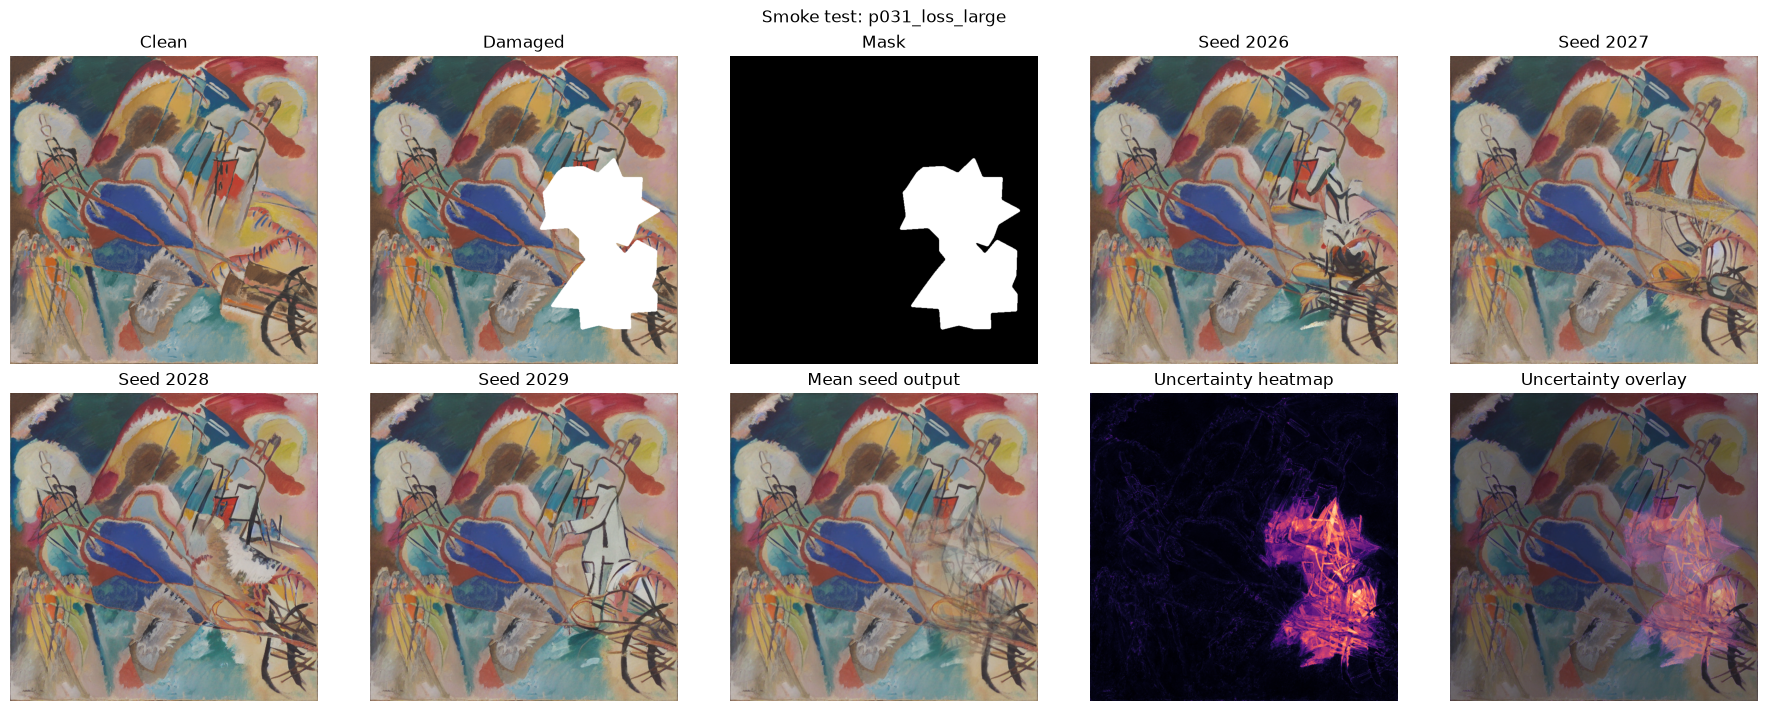

Smoke test completed.


In [10]:
smoke_case_id = standardized_generations_df["case_id"].drop_duplicates().iloc[0]

smoke_case_df = standardized_generations_df[
    standardized_generations_df["case_id"] == smoke_case_id
].copy()

print("Smoke-test case:", smoke_case_id)
print("Smoke-test rows:", smoke_case_df.shape)
display(smoke_case_df[["case_id", "painting_id", "mask_type", "category", "seed", "generated_image_path"]])

smoke_result = compute_case_uncertainty(smoke_case_df)

print("Smoke-test summary:")
display(pd.DataFrame([smoke_result["summary"]]))

smoke_arrays = smoke_result["arrays"]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 7),
    constrained_layout=True,
)

seed_images = smoke_arrays["seed_images"]
seed_values = smoke_arrays["seed_values"]

top_panels = [
    ("Clean", smoke_arrays["clean_image"]),
    ("Damaged", smoke_arrays["damaged_image"]),
    ("Mask", smoke_arrays["mask_array"]),
    (f"Seed {seed_values[0]}", seed_images[0]),
    (f"Seed {seed_values[1]}", seed_images[1]),
]

bottom_panels = [
    (f"Seed {seed_values[2]}", seed_images[2]),
    (f"Seed {seed_values[3]}", seed_images[3]),
    ("Mean seed output", smoke_arrays["mean_generated_image"].astype(np.uint8)),
    ("Uncertainty heatmap", smoke_arrays["uncertainty_heatmap"]),
    ("Uncertainty overlay", smoke_arrays["overlay_image"]),
]

for axis, (title, image) in zip(axes[0], top_panels):
    if image.ndim == 2:
        axis.imshow(image, cmap="gray")
    else:
        axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

    axis.set_title(title)
    axis.axis("off")

for axis, (title, image) in zip(axes[1], bottom_panels):
    if "heatmap" in title.lower():
        axis.imshow(image, cmap="magma")
    elif image.ndim == 2:
        axis.imshow(image, cmap="gray")
    else:
        axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

    axis.set_title(title)
    axis.axis("off")

fig.suptitle(
    f"Smoke test: {smoke_case_id}",
    fontsize=12,
)

plt.show()

print("Smoke test completed.")

In [11]:
heatmap_summary_rows = []
heatmap_manifest_rows = []

case_groups = list(standardized_generations_df.groupby("case_id"))

print("Computing uncertainty heatmaps for cases:", len(case_groups))

for case_index, (case_id, case_df) in enumerate(case_groups, start=1):
    print(f"[{case_index:02d}/{len(case_groups):02d}] {case_id}")

    try:
        case_result = compute_case_uncertainty(case_df)

        saved_paths = save_case_heatmap_outputs(
            case_result,
            save_compact_figure=True,
        )

        summary = case_result["summary"].copy()
        summary.update(saved_paths)
        summary["heatmap_status"] = "ok"
        summary["heatmap_error_message"] = ""

    except Exception as error:
        first_row = case_df.iloc[0]

        summary = {
            "case_id": str(case_id),
            "painting_id": str(first_row.get("painting_id", "")),
            "mask_id": str(first_row.get("mask_id", "")),
            "mask_type": str(first_row.get("mask_type", "")),
            "category": str(first_row.get("category", "")),
            "seed_count": int(case_df["seed"].nunique()) if "seed" in case_df.columns else np.nan,
            "heatmap_status": "error",
            "heatmap_error_message": str(error),
        }

    heatmap_summary_rows.append(summary)

heatmap_summary_by_case_df = pd.DataFrame(heatmap_summary_rows)

heatmap_summary_by_case_df.to_csv(
    heatmap_output_paths["heatmap_summary_by_case"],
    index=False,
)

heatmap_manifest_df = heatmap_summary_by_case_df[
    [
        column
        for column in [
            "case_id",
            "painting_id",
            "mask_id",
            "mask_type",
            "category",
            "seed_count",
            "heatmap_status",
            "heatmap_png_path",
            "overlay_png_path",
            "compact_figure_path",
            "heatmap_error_message",
        ]
        if column in heatmap_summary_by_case_df.columns
    ]
].copy()

heatmap_manifest_df.to_csv(
    heatmap_output_paths["heatmap_manifest"],
    index=False,
)

print("Heatmap summary by case:", heatmap_summary_by_case_df.shape)
print("Saved:", heatmap_output_paths["heatmap_summary_by_case"])
print("Saved:", heatmap_output_paths["heatmap_manifest"])

print("\nHeatmap status counts:")
display(
    heatmap_summary_by_case_df["heatmap_status"]
    .value_counts(dropna=False)
    .rename_axis("heatmap_status")
    .reset_index(name="case_count")
)

if (heatmap_summary_by_case_df["heatmap_status"] != "ok").any():
    display(
        heatmap_summary_by_case_df[
            heatmap_summary_by_case_df["heatmap_status"] != "ok"
        ]
    )

    raise ValueError("Some uncertainty heatmap cases failed.")

display(heatmap_summary_by_case_df.head())

Computing uncertainty heatmaps for cases: 40
[01/40] p009_loss_large
[02/40] p009_loss_small
[03/40] p009_mixed_damage
[04/40] p009_scratch_thin
[05/40] p010_loss_large
[06/40] p010_loss_small
[07/40] p010_mixed_damage
[08/40] p010_scratch_thin
[09/40] p011_loss_large
[10/40] p011_loss_small
[11/40] p011_mixed_damage
[12/40] p011_scratch_thin
[13/40] p018_loss_large
[14/40] p018_loss_small
[15/40] p018_mixed_damage
[16/40] p018_scratch_thin
[17/40] p021_loss_large
[18/40] p021_loss_small
[19/40] p021_mixed_damage
[20/40] p021_scratch_thin
[21/40] p026_loss_large
[22/40] p026_loss_small
[23/40] p026_mixed_damage
[24/40] p026_scratch_thin
[25/40] p031_loss_large
[26/40] p031_loss_small
[27/40] p031_mixed_damage
[28/40] p031_scratch_thin
[29/40] p037_loss_large
[30/40] p037_loss_small
[31/40] p037_mixed_damage
[32/40] p037_scratch_thin
[33/40] p041_loss_large
[34/40] p041_loss_small
[35/40] p041_mixed_damage
[36/40] p041_scratch_thin
[37/40] p043_loss_large
[38/40] p043_loss_small
[39/40]

,heatmap_status,case_count
0,ok,40


,case_id,painting_id,mask_id,mask_type,category,seed_count,seeds,bbox_margin,boundary_dilation_iterations,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max,bbox_width,bbox_height,mask_pixel_count,boundary_ring_pixel_count,image_height,image_width,clean_image_path,damaged_image_path,mask_path,global_pixel_count,global_mean_uncertainty,global_median_uncertainty,global_std_uncertainty,global_max_uncertainty,global_p95_uncertainty,masked_pixel_count,masked_mean_uncertainty,masked_median_uncertainty,masked_std_uncertainty,masked_max_uncertainty,masked_p95_uncertainty,bbox_pixel_count,bbox_mean_uncertainty,bbox_median_uncertainty,bbox_std_uncertainty,bbox_max_uncertainty,bbox_p95_uncertainty,boundary_pixel_count,boundary_mean_uncertainty,boundary_median_uncertainty,boundary_std_uncertainty,boundary_max_uncertainty,boundary_p95_uncertainty,outside_mask_pixel_count,outside_mask_mean_uncertainty,outside_mask_median_uncertainty,outside_mask_std_uncertainty,outside_mask_max_uncertainty,outside_mask_p95_uncertainty,masked_vs_global_mean_uncertainty_ratio,boundary_vs_global_mean_uncertainty_ratio,outside_vs_global_mean_uncertainty_ratio,heatmap_png_path,overlay_png_path,compact_figure_path,heatmap_status,heatmap_error_message
0,p009_loss_large,p009,p009_loss_large,loss_large,portrait_figure,4,"2026,2027,2028,2029",16,8,114,5,425,353,311,348,58251,11188,768,768,data/processed/clean/p009_clean.png,data/processed/masked/p009_loss_large_damaged.png,data/processed/masks/p009_loss_large_mask.png,589824,7.139126,3.315714,11.713877,90.903809,36.279317,58251,37.621746,36.474518,17.323160,90.903809,68.591263,108228,22.943476,15.369257,20.564123,90.903809,63.103390,11188,8.283583,6.111487,6.086686,49.875126,20.399110,531573,3.798770,3.110447,2.526996,54.922409,8.151491,5.269797,1.160308,0.532106,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,outputs/figures/uncertainty_heatmaps/all_cases...,ok,
1,p009_loss_small,p009,p009_loss_small,loss_small,portrait_figure,4,"2026,2027,2028,2029",16,8,74,12,608,725,534,713,20955,17768,768,768,data/processed/clean/p009_clean.png,data/processed/masked/p009_loss_small_damaged.png,data/processed/masks/p009_loss_small_mask.png,589824,3.792632,2.460474,4.772146,72.965721,10.358957,20955,20.308403,18.510866,12.400115,72.965721,43.849069,380742,4.641004,2.976457,5.617824,72.965721,13.690309,17768,7.622290,5.569912,6.147393,61.105042,20.243643,568869,3.184254,2.383144,2.744128,61.105042,8.017471,5.354699,2.009762,0.839589,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,outputs/figures/uncertainty_heatmaps/all_cases...,ok,
2,p009_mixed_damage,p009,p009_mixed_damage,mixed_damage,portrait_figure,4,"2026,2027,2028,2029",16,8,59,22,695,768,636,746,47792,58080,768,768,data/processed/clean/p009_clean.png,data/processed/masked/p009_mixed_damage_damage...,data/processed/masks/p009_mixed_damage_mask.png,589824,5.203534,2.796946,6.918035,79.457863,19.489065,47792,21.450689,19.825096,12.087997,79.457863,43.381599,474456,6.108598,3.473705,7.423001,79.457863,22.247615,58080,8.090476,6.219815,6.228711,67.636040,20.532101,542032,3.770992,2.559111,3.724039,67.636040,10.581870,4.122331,1.554804,0.724698,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,outputs/figures/uncertainty_heatmaps/all_cases...,ok,
3,p009_scratch_thin,p009,p009_scratch_thin,scratch_thin,portrait_figure,4,"2026,2027,2028,2029",16,8,59,43,708,751,649,708,9528,57787,768,768,data/processed/clean/p009_clean.png,data/processed/masked/p009_scratch_thin_damage...,data/processed/masks/p009_scratch_thin_mask.png,589824,3.316188,2.284334,3.465595,63.512772,9.101201,9528,13.612813,10.551676,9.681342,63.512585,33.434691,459492,3.783984,2.668498,3.728631,63.512772,10.115618,57787,6.019396,4.239167,5.445668,63.512772,17.077961,580296,3.147125,2.250875,2.983160,63.512772,8.420557,4.104958,1.815155,0.949019,outputs/figures/uncertainty_he

In [12]:
valid_heatmap_df = heatmap_summary_by_case_df[
    heatmap_summary_by_case_df["heatmap_status"] == "ok"
].copy()

summary_metric_columns = [
    "global_mean_uncertainty",
    "global_p95_uncertainty",
    "masked_mean_uncertainty",
    "masked_p95_uncertainty",
    "bbox_mean_uncertainty",
    "bbox_p95_uncertainty",
    "boundary_mean_uncertainty",
    "boundary_p95_uncertainty",
    "outside_mask_mean_uncertainty",
    "outside_mask_p95_uncertainty",
    "masked_vs_global_mean_uncertainty_ratio",
    "boundary_vs_global_mean_uncertainty_ratio",
    "outside_vs_global_mean_uncertainty_ratio",
]

missing_summary_metric_columns = [
    column
    for column in summary_metric_columns
    if column not in valid_heatmap_df.columns
]

if missing_summary_metric_columns:
    raise ValueError(
        f"Missing summary metric columns: {missing_summary_metric_columns}"
    )

heatmap_summary_by_mask_type_df = (
    valid_heatmap_df
    .groupby("mask_type", as_index=False)
    .agg(
        cases=("case_id", "count"),
        mean_global_uncertainty=("global_mean_uncertainty", "mean"),
        mean_masked_uncertainty=("masked_mean_uncertainty", "mean"),
        median_masked_uncertainty=("masked_mean_uncertainty", "median"),
        mean_bbox_uncertainty=("bbox_mean_uncertainty", "mean"),
        mean_boundary_uncertainty=("boundary_mean_uncertainty", "mean"),
        mean_outside_mask_uncertainty=("outside_mask_mean_uncertainty", "mean"),
        mean_masked_vs_global_ratio=("masked_vs_global_mean_uncertainty_ratio", "mean"),
        mean_boundary_vs_global_ratio=("boundary_vs_global_mean_uncertainty_ratio", "mean"),
    )
    .sort_values("mean_masked_uncertainty", ascending=False)
)

heatmap_summary_by_mask_type_df.to_csv(
    heatmap_output_paths["heatmap_summary_by_mask_type"],
    index=False,
)

heatmap_summary_by_category_df = (
    valid_heatmap_df
    .groupby("category", as_index=False)
    .agg(
        cases=("case_id", "count"),
        mean_global_uncertainty=("global_mean_uncertainty", "mean"),
        mean_masked_uncertainty=("masked_mean_uncertainty", "mean"),
        median_masked_uncertainty=("masked_mean_uncertainty", "median"),
        mean_bbox_uncertainty=("bbox_mean_uncertainty", "mean"),
        mean_boundary_uncertainty=("boundary_mean_uncertainty", "mean"),
        mean_outside_mask_uncertainty=("outside_mask_mean_uncertainty", "mean"),
        mean_masked_vs_global_ratio=("masked_vs_global_mean_uncertainty_ratio", "mean"),
        mean_boundary_vs_global_ratio=("boundary_vs_global_mean_uncertainty_ratio", "mean"),
    )
    .sort_values("mean_masked_uncertainty", ascending=False)
)

heatmap_summary_by_category_df.to_csv(
    heatmap_output_paths["heatmap_summary_by_category"],
    index=False,
)

print("Heatmap summary by mask type:")
display(heatmap_summary_by_mask_type_df)
print("Saved:", heatmap_output_paths["heatmap_summary_by_mask_type"])

print("Heatmap summary by category:")
display(heatmap_summary_by_category_df)
print("Saved:", heatmap_output_paths["heatmap_summary_by_category"])

Heatmap summary by mask type:


,mask_type,cases,mean_global_uncertainty,mean_masked_uncertainty,median_masked_uncertainty,mean_bbox_uncertainty,mean_boundary_uncertainty,mean_outside_mask_uncertainty,mean_masked_vs_global_ratio,mean_boundary_vs_global_ratio
0,loss_large,10,4.750954,24.622568,22.084580,14.702201,6.614203,2.546994,5.362492,1.419112
2,mixed_damage,10,4.050491,17.688853,17.553786,4.718454,6.024136,2.896445,4.499372,1.461297
1,loss_small,10,2.985344,16.047955,15.562322,3.971199,6.301782,2.494192,5.500481,2.095952
3,scratch_thin,10,2.860343,12.074715,11.957541,3.267405,5.300038,2.692350,4.432006,1.887867


Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_heatmap_summary_by_mask_type_50.csv
Heatmap summary by category:


,category,cases,mean_global_uncertainty,mean_masked_uncertainty,median_masked_uncertainty,mean_bbox_uncertainty,mean_boundary_uncertainty,mean_outside_mask_uncertainty,mean_masked_vs_global_ratio,mean_boundary_vs_global_ratio
0,abstraction_surrealism,8,3.711135,20.055819,21.057585,6.663922,5.623687,2.446155,5.682910,1.594331
3,landscape_natural,8,3.005084,19.835183,17.513558,6.691588,4.645026,1.845033,6.442190,1.656302
4,portrait_figure,8,4.619064,18.022746,15.380100,7.594927,7.170386,3.537830,3.835811,1.632620
2,high_texture_brushwork,8,3.856592,15.738840,16.219893,6.582487,7.371399,3.011359,4.160744,1.901402
1,architecture_structured,8,3.117041,14.390026,13.334217,5.791148,5.489702,2.447099,4.621284,1.795631


Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_heatmap_summary_by_category_50.csv


In [13]:
def prepare_case_level_lookup(
    df: pd.DataFrame,
    *,
    source_name: str,
) -> pd.DataFrame:
    """
    Prepare case-level lookup data using Notebook 27's original_case_id when available.
    """
    prepared_df = df.copy()

    if "original_case_id" in prepared_df.columns:
        prepared_df["case_id"] = prepared_df["original_case_id"].astype(str)
    elif "case_id" in prepared_df.columns:
        prepared_df["case_id"] = prepared_df["case_id"].astype(str)
    else:
        print(f"{source_name}: no case key column found.")
        return pd.DataFrame({"case_id": []})

    prepared_df = prepared_df.drop_duplicates(subset=["case_id"]).reset_index(drop=True)

    return prepared_df


uncertainty_vs_refined_lookup_df = prepare_case_level_lookup(
    uncertainty_vs_refined_df,
    source_name="uncertainty_vs_refined_df",
)

uncertainty_quadrants_lookup_df = prepare_case_level_lookup(
    uncertainty_quadrants_df,
    source_name="uncertainty_quadrants_df",
)

heatmap_performance_linkage_df = valid_heatmap_df.copy()
heatmap_performance_linkage_df["case_id"] = heatmap_performance_linkage_df["case_id"].astype(str)

if not uncertainty_vs_refined_lookup_df.empty:
    columns_to_merge = [
        column
        for column in uncertainty_vs_refined_lookup_df.columns
        if column not in heatmap_performance_linkage_df.columns or column == "case_id"
    ]

    heatmap_performance_linkage_df = heatmap_performance_linkage_df.merge(
        uncertainty_vs_refined_lookup_df[columns_to_merge],
        on="case_id",
        how="left",
    )

if not uncertainty_quadrants_lookup_df.empty:
    columns_to_merge = [
        column
        for column in uncertainty_quadrants_lookup_df.columns
        if column not in heatmap_performance_linkage_df.columns or column == "case_id"
    ]

    heatmap_performance_linkage_df = heatmap_performance_linkage_df.merge(
        uncertainty_quadrants_lookup_df[columns_to_merge],
        on="case_id",
        how="left",
    )

heatmap_performance_linkage_df.to_csv(
    heatmap_output_paths["heatmap_performance_linkage"],
    index=False,
)

print("Heatmap-performance linkage:", heatmap_performance_linkage_df.shape)
print("Saved:", heatmap_output_paths["heatmap_performance_linkage"])

print("Columns available for later selected-case logic:")
display(pd.DataFrame({"column": heatmap_performance_linkage_df.columns}))

display(heatmap_performance_linkage_df.head())

uncertainty_quadrants_df: no case key column found.
Heatmap-performance linkage: (40, 119)
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_heatmap_vs_refined_performance_50.csv
Columns available for later selected-case logic:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,category
...,...
114,winner_dinov2_improvement
115,stable_diffusion_won_refined_vote
116,stable_diffusion_zero_metric_wins
117,stable_diffusion_low_metric_wins


,case_id,painting_id,mask_id,mask_type,category,seed_count,seeds,bbox_margin,boundary_dilation_iterations,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max,bbox_width,bbox_height,mask_pixel_count,boundary_ring_pixel_count,image_height,image_width,clean_image_path,damaged_image_path,mask_path,global_pixel_count,global_mean_uncertainty,global_median_uncertainty,global_std_uncertainty,global_max_uncertainty,global_p95_uncertainty,masked_pixel_count,masked_mean_uncertainty,masked_median_uncertainty,masked_std_uncertainty,masked_max_uncertainty,masked_p95_uncertainty,bbox_pixel_count,bbox_mean_uncertainty,bbox_median_uncertainty,bbox_std_uncertainty,bbox_max_uncertainty,bbox_p95_uncertainty,boundary_pixel_count,boundary_mean_uncertainty,boundary_median_uncertainty,boundary_std_uncertainty,boundary_max_uncertainty,boundary_p95_uncertainty,outside_mask_pixel_count,outside_mask_mean_uncertainty,outside_mask_median_uncertainty,outside_mask_std_uncertainty,outside_mask_max_uncertainty,outside_mask_p95_uncertainty,masked_vs_global_mean_uncertainty_ratio,boundary_vs_global_mean_uncertainty_ratio,outside_vs_global_mean_uncertainty_ratio,heatmap_png_path,overlay_png_path,compact_figure_path,heatmap_status,heatmap_error_message,original_case_id,title,uncertainty_selection_role,num_seed_outputs,mask_fraction,full_std_mean,full_std_max,full_variance_mean,full_mad_mean,masked_std_mean,masked_std_max,masked_variance_mean,masked_mad_mean,bbox_std_mean,bbox_std_max,bbox_variance_mean,bbox_mad_mean,lpips_pair_count,mean_pairwise_lpips,median_pairwise_lpips,max_pairwise_lpips,range_pairwise_lpips,feature_pair_count,mean_pairwise_clip_similarity,mean_pairwise_dinov2_similarity,mean_clip_uncertainty_distance,mean_dinov2_uncertainty_distance,max_clip_uncertainty_distance,max_dinov2_uncertainty_distance,range_pairwise_clip_similarity,range_pairwise_dinov2_similarity,masked_std_mean_normalized,masked_mad_mean_normalized,bbox_std_mean_normalized,mean_pairwise_lpips_normalized,mean_clip_uncertainty_distance_normalized,mean_dinov2_uncertainty_distance_normalized,combined_uncertainty_index,uncertainty_rank_high_to_low,refined_overall_metric_vote,refined_metric_ties,refined_mixed_metric_outcome,refined_stable_diffusion_metric_wins,stable_diffusion_inpainting_mse_improvement,stable_diffusion_inpainting_psnr_improvement,stable_diffusion_inpainting_ssim_improvement,stable_diffusion_inpainting_lpips_improvement,stable_diffusion_inpainting_clip_improvement,stable_diffusion_inpainting_dinov2_improvement,winner_mse_improvement,winner_psnr_improvement,winner_ssim_improvement,winner_lpips_improvement,winner_clip_improvement,winner_dinov2_improvement,stable_diffusion_won_refined_vote,stable_diffusion_zero_metric_wins,stable_diffusion_low_metric_wins,uncertainty_performance_quadrant
0,p009_loss_large,p009,p009_loss_large,loss_large,portrait_figure,4,"2026,2027,2028,2029",16,8,114,5,425,353,311,348,58251,11188,768,768,data/processed/clean/p009_clean.png,data/processed/masked/p009_loss_large_damaged.png,data/processed/masks/p009_loss_large_mask.png,589824,7.139126,3.315714,11.713877,90.903809,36.279317,58251,37.621746,36.474518,17.323160,90.903809,68.591263,108228,22.943476,15.369257,20.564123,90.903809,63.103390,11188,8.283583,6.111487,6.086686,49.875126,20.399110,531573,3.798770,3.110447,2.526996,54.922409,8.151491,5.269797,1.160308,0.532106,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,outputs/figures/uncertainty_heatmaps/all_cases...,ok,,p009_loss_large,Madame Roulin and Her Baby,relatively_strong_stable_diffusion,4,0.098760,0.027997,0.356486,0.003159,0.024305,0.147536,0.356486,0.028788,0.129001,0.089974,0.356486,0.015927,0.078577,6,0.372464,0.368409,0.403039,0.058481,6,0.923193,0.845759,0.076807,0.154241,0.095121,0.226657,0.058676,0.119343,0.978643,0.957906,1.000000,0.823996,0.315576,0.239388,0.719251,2,lama,0,True,2,14208.727539,4.910093,-0.240267,0.193873,0.139452,0.191036,lama,lama,opencv_telea,lama,stable_diffusion_

In [14]:
selected_case_records = []


def add_selected_cases(
    source_df: pd.DataFrame,
    *,
    reason: str,
    max_cases: int,
    sort_column: str,
    ascending: bool,
) -> None:
    if sort_column not in source_df.columns:
        print(f"Skipping selection reason '{reason}' because column is missing: {sort_column}")
        return

    selected_df = (
        source_df
        .sort_values(sort_column, ascending=ascending)
        .head(max_cases)
    )

    for _, row in selected_df.iterrows():
        selected_case_records.append(
            {
                "case_id": row["case_id"],
                "selection_reason": reason,
                "selection_sort_column": sort_column,
                "selection_sort_value": row[sort_column],
            }
        )


# Core fixed selections.
add_selected_cases(
    heatmap_performance_linkage_df,
    reason="highest_masked_uncertainty",
    max_cases=5,
    sort_column="masked_mean_uncertainty",
    ascending=False,
)

add_selected_cases(
    heatmap_performance_linkage_df,
    reason="lowest_masked_uncertainty",
    max_cases=5,
    sort_column="masked_mean_uncertainty",
    ascending=True,
)

add_selected_cases(
    heatmap_performance_linkage_df,
    reason="highest_boundary_uncertainty",
    max_cases=5,
    sort_column="boundary_mean_uncertainty",
    ascending=False,
)

add_selected_cases(
    heatmap_performance_linkage_df,
    reason="highest_outside_mask_uncertainty",
    max_cases=3,
    sort_column="outside_mask_mean_uncertainty",
    ascending=False,
)

# One representative case per category with highest masked uncertainty.
for category, category_df in heatmap_performance_linkage_df.groupby("category"):
    add_selected_cases(
        category_df,
        reason=f"category_representative_high_uncertainty__{category}",
        max_cases=1,
        sort_column="masked_mean_uncertainty",
        ascending=False,
    )

# One representative case per mask type with highest masked uncertainty.
for mask_type, mask_df in heatmap_performance_linkage_df.groupby("mask_type"):
    add_selected_cases(
        mask_df,
        reason=f"mask_type_representative_high_uncertainty__{mask_type}",
        max_cases=1,
        sort_column="masked_mean_uncertainty",
        ascending=False,
    )

# Quadrant selections if Notebook 27 exposes a quadrant-like column.
quadrant_column = None

for candidate in [
    "uncertainty_performance_quadrant",
    "performance_uncertainty_quadrant",
    "quadrant",
    "quadrant_label",
]:
    if candidate in heatmap_performance_linkage_df.columns:
        quadrant_column = candidate
        break

if quadrant_column is not None:
    for quadrant_value, quadrant_df in heatmap_performance_linkage_df.groupby(quadrant_column):
        add_selected_cases(
            quadrant_df,
            reason=f"uncertainty_performance_quadrant__{quadrant_value}",
            max_cases=2,
            sort_column="masked_mean_uncertainty",
            ascending=False,
        )

selected_reasons_df = pd.DataFrame(selected_case_records)

if selected_reasons_df.empty:
    raise ValueError("No selected uncertainty heatmap cases were generated.")

selected_reasons_grouped_df = (
    selected_reasons_df
    .groupby("case_id", as_index=False)
    .agg(
        selection_reasons=("selection_reason", lambda values: "; ".join(sorted(set(values)))),
        selection_count=("selection_reason", "count"),
        first_selection_sort_column=("selection_sort_column", "first"),
        first_selection_sort_value=("selection_sort_value", "first"),
    )
)

selected_heatmap_cases_df = selected_reasons_grouped_df.merge(
    heatmap_performance_linkage_df,
    on="case_id",
    how="left",
)

selected_heatmap_cases_df = selected_heatmap_cases_df.sort_values(
    ["selection_count", "masked_mean_uncertainty"],
    ascending=[False, False],
).reset_index(drop=True)

selected_heatmap_cases_df.to_csv(
    heatmap_output_paths["heatmap_selected_cases"],
    index=False,
)

print("Selected uncertainty heatmap cases:", selected_heatmap_cases_df.shape)
print("Quadrant column used:", quadrant_column)
print("Saved:", heatmap_output_paths["heatmap_selected_cases"])

display(
    selected_heatmap_cases_df[
        [
            column
            for column in [
                "case_id",
                "category",
                "mask_type",
                "selection_reasons",
                "selection_count",
                "masked_mean_uncertainty",
                "boundary_mean_uncertainty",
                "outside_mask_mean_uncertainty",
                quadrant_column,
            ]
            if column is not None and column in selected_heatmap_cases_df.columns
        ]
    ].head(25)
)

Selected uncertainty heatmap cases: (22, 123)
Quadrant column used: uncertainty_performance_quadrant
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_uncertainty_heatmap_selected_cases_50.csv


,case_id,category,mask_type,selection_reasons,selection_count,masked_mean_uncertainty,boundary_mean_uncertainty,outside_mask_mean_uncertainty,uncertainty_performance_quadrant
0,p011_loss_large,landscape_natural,loss_large,category_representative_high_uncertainty__land...,4,38.245800,4.813465,1.559997,high_uncertainty_low_reference_performance
1,p009_loss_large,portrait_figure,loss_large,category_representative_high_uncertainty__port...,4,37.621746,8.283583,3.798770,high_uncertainty_high_reference_performance
2,p031_loss_large,abstraction_surrealism,loss_large,category_representative_high_uncertainty__abst...,3,27.727493,7.723886,3.094143,high_uncertainty_low_reference_performance
3,p037_loss_large,abstraction_surrealism,loss_large,highest_masked_uncertainty; uncertainty_perfor...,2,25.150114,3.572868,1.621859,high_uncertainty_high_reference_performance
4,p011_mixed_damage,landscape_natural,mixed_damage,highest_masked_uncertainty; mask_type_represen...,2,24.741758,4.385314,1.783683,high_uncertainty_low_reference_performance
5,p037_loss_small,abstraction_surrealism,loss_small,mask_type_representative_high_uncertainty__los...,2,22.331778,5.407199,1.794383,middle_region
6,p041_mixed_damage,high_texture_brushwork,mixed_damage,highest_boundary_uncertainty; highest_outside_...,2,18.264513,10.275064,3.833238,middle_region
7,p041_scratch_thin,high_texture_brushwork,scratch_thin,highest_outside_mask_uncertainty; lowest_maske...,2,10.916192,7.015200,3.933914,low_uncertainty_low_reference_performance
8,p037_mixed_damage,abstraction_surrealism,mixed_damage,uncertainty_performance_quadrant__middle_region,1,22.276716,4.110384,1.942242,middle_region
9,p043_loss_large,high_texture_brushwork,loss_large,category_representative_high_uncertainty__high...,1,21.625156,6.009873,2.034851,high_uncertainty_high_reference_performance


In [15]:
def save_selected_case_detailed_figure(
    case_generation_df: pd.DataFrame,
    selected_case_row: pd.Series,
) -> str:
    """
    Save detailed 2-row figure for a selected uncertainty case.

    Layout:
    Row 1: clean, damaged, mask, seed 1, seed 2
    Row 2: seed 3, seed 4, mean output, heatmap, overlay
    """
    case_result = compute_case_uncertainty(case_generation_df)
    summary = case_result["summary"]
    arrays = case_result["arrays"]

    case_id = summary["case_id"]
    safe_case_id = str(case_id).replace("/", "_").replace("\\", "_").replace(":", "_")

    output_path = uncertainty_selected_cases_dir / f"{safe_case_id}_uncertainty_selected_detail.png"

    seed_images = arrays["seed_images"]
    seed_values = arrays["seed_values"]

    if len(seed_images) != 4:
        raise ValueError(
            f"Selected case {case_id} expected 4 seed images, found {len(seed_images)}."
        )

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(20, 8),
        constrained_layout=True,
    )

    top_panels = [
        ("Clean", arrays["clean_image"]),
        ("Damaged", arrays["damaged_image"]),
        ("Mask", arrays["mask_array"]),
        (f"Seed {seed_values[0]}", seed_images[0]),
        (f"Seed {seed_values[1]}", seed_images[1]),
    ]

    bottom_panels = [
        (f"Seed {seed_values[2]}", seed_images[2]),
        (f"Seed {seed_values[3]}", seed_images[3]),
        ("Mean seed output", arrays["mean_generated_image"].astype(np.uint8)),
        ("Uncertainty heatmap", arrays["uncertainty_heatmap"]),
        ("Heatmap overlay", arrays["overlay_image"]),
    ]

    for axis, (title, image) in zip(axes[0], top_panels):
        if image.ndim == 2:
            axis.imshow(image, cmap="gray")
        else:
            axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

        axis.set_title(title)
        axis.axis("off")

    for axis, (title, image) in zip(axes[1], bottom_panels):
        if title == "Uncertainty heatmap":
            axis.imshow(image, cmap="magma")
        elif image.ndim == 2:
            axis.imshow(image, cmap="gray")
        else:
            axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

        axis.set_title(title)
        axis.axis("off")

    title = (
        f"{case_id} | {summary['category']} | {summary['mask_type']}\n"
        f"masked mean={summary['masked_mean_uncertainty']:.3f}, "
        f"boundary mean={summary['boundary_mean_uncertainty']:.3f}, "
        f"outside mean={summary['outside_mask_mean_uncertainty']:.3f}\n"
        f"selection: {selected_case_row.get('selection_reasons', '')}"
    )

    fig.suptitle(title, fontsize=11)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=140)
    plt.close(fig)

    return to_project_relative_path(output_path)


selected_detail_paths = []

for index, selected_row in selected_heatmap_cases_df.iterrows():
    case_id = selected_row["case_id"]

    case_generation_df = standardized_generations_df[
        standardized_generations_df["case_id"] == case_id
    ].copy()

    if case_generation_df.empty:
        raise ValueError(f"No generation rows found for selected case: {case_id}")

    print(f"[{index + 1:02d}/{len(selected_heatmap_cases_df):02d}] selected detail: {case_id}")

    detail_path = save_selected_case_detailed_figure(
        case_generation_df,
        selected_row,
    )

    selected_detail_paths.append(
        {
            "case_id": case_id,
            "selected_detail_figure_path": detail_path,
        }
    )

selected_detail_paths_df = pd.DataFrame(selected_detail_paths)

selected_heatmap_cases_df = selected_heatmap_cases_df.merge(
    selected_detail_paths_df,
    on="case_id",
    how="left",
)

selected_heatmap_cases_df.to_csv(
    heatmap_output_paths["heatmap_selected_cases"],
    index=False,
)

print("Selected detailed figures generated:", len(selected_detail_paths_df))
print("Updated selected cases file:", heatmap_output_paths["heatmap_selected_cases"])

display(
    selected_heatmap_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reasons",
            "selected_detail_figure_path",
        ]
    ].head(20)
)

[01/22] selected detail: p011_loss_large
[02/22] selected detail: p009_loss_large
[03/22] selected detail: p031_loss_large
[04/22] selected detail: p037_loss_large
[05/22] selected detail: p011_mixed_damage
[06/22] selected detail: p037_loss_small
[07/22] selected detail: p041_mixed_damage
[08/22] selected detail: p041_scratch_thin
[09/22] selected detail: p037_mixed_damage
[10/22] selected detail: p043_loss_large
[11/22] selected detail: p009_mixed_damage
[12/22] selected detail: p026_loss_large
[13/22] selected detail: p041_loss_large
[14/22] selected detail: p018_scratch_thin
[15/22] selected detail: p041_loss_small
[16/22] selected detail: p009_scratch_thin
[17/22] selected detail: p037_scratch_thin
[18/22] selected detail: p010_mixed_damage
[19/22] selected detail: p026_scratch_thin
[20/22] selected detail: p021_scratch_thin
[21/22] selected detail: p011_scratch_thin
[22/22] selected detail: p010_loss_small
Selected detailed figures generated: 22
Updated selected cases file: D:\Ma

,case_id,category,mask_type,selection_reasons,selected_detail_figure_path
0,p011_loss_large,landscape_natural,loss_large,category_representative_high_uncertainty__land...,outputs/figures/uncertainty_heatmaps/selected_...
1,p009_loss_large,portrait_figure,loss_large,category_representative_high_uncertainty__port...,outputs/figures/uncertainty_heatmaps/selected_...
2,p031_loss_large,abstraction_surrealism,loss_large,category_representative_high_uncertainty__abst...,outputs/figures/uncertainty_heatmaps/selected_...
3,p037_loss_large,abstraction_surrealism,loss_large,highest_masked_uncertainty; uncertainty_perfor...,outputs/figures/uncertainty_heatmaps/selected_...
4,p011_mixed_damage,landscape_natural,mixed_damage,highest_masked_uncertainty; mask_type_represen...,outputs/figures/uncertainty_heatmaps/selected_...
5,p037_loss_small,abstraction_surrealism,loss_small,mask_type_representative_high_uncertainty__los...,outputs/figures/uncertainty_heatmaps/selected_...
6,p041_mixed_damage,high_texture_brushwork,mixed_damage,highest_boundary_uncertainty; highest_outside_...,outputs/figures/uncertainty_heatmaps/selected_...
7,p041_scratch_thin,high_texture_brushwork,scratch_thin,highest_outside_mask_uncertainty; lowest_maske...,outputs/figures/uncertainty_heatmaps/selected_...
8,p037_mixed_damage,abstraction_surrealism,mixed_damage,uncertainty_performance_quadrant__middle_region,outputs/figures/uncertainty_heatmaps/selected_...
9,p043_loss_large,high_texture_brushwork,loss_large,category_representative_high_uncertainty__high...,outputs/figures/uncertainty_heatmaps/selected_...


In [16]:
def save_bar_figure(
    df: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    title: str,
    xlabel: str,
    ylabel: str,
    output_path: Path,
    rotation: int = 30,
) -> None:
    if df.empty:
        raise ValueError(f"Cannot plot empty dataframe for: {title}")

    if x_column not in df.columns:
        raise ValueError(f"Missing x column: {x_column}")

    if y_column not in df.columns:
        raise ValueError(f"Missing y column: {y_column}")

    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, axis = plt.subplots(figsize=(10, 5))

    axis.bar(
        df[x_column].astype(str),
        df[y_column],
    )

    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=rotation)

    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.close(fig)

    print("Saved:", output_path)


print("Plot helper ready.")

Plot helper ready.


In [17]:
save_bar_figure(
    heatmap_summary_by_mask_type_df,
    x_column="mask_type",
    y_column="mean_masked_uncertainty",
    title="Mean masked-region seed uncertainty by mask type",
    xlabel="Mask type",
    ylabel="Mean masked-region uncertainty",
    output_path=heatmap_figure_paths["masked_uncertainty_by_mask_type"],
    rotation=30,
)

save_bar_figure(
    heatmap_summary_by_mask_type_df,
    x_column="mask_type",
    y_column="mean_bbox_uncertainty",
    title="Mean mask-bounding-box seed uncertainty by mask type",
    xlabel="Mask type",
    ylabel="Mean bbox uncertainty",
    output_path=heatmap_figure_paths["bbox_uncertainty_by_mask_type"],
    rotation=30,
)

save_bar_figure(
    heatmap_summary_by_mask_type_df,
    x_column="mask_type",
    y_column="mean_boundary_uncertainty",
    title="Mean boundary-ring seed uncertainty by mask type",
    xlabel="Mask type",
    ylabel="Mean boundary-ring uncertainty",
    output_path=heatmap_figure_paths["boundary_uncertainty_by_mask_type"],
    rotation=30,
)

Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\masked_uncertainty_by_mask_type.png
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\bbox_uncertainty_by_mask_type.png
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\boundary_uncertainty_by_mask_type.png


In [18]:
save_bar_figure(
    heatmap_summary_by_category_df,
    x_column="category",
    y_column="mean_masked_uncertainty",
    title="Mean masked-region seed uncertainty by painting category",
    xlabel="Painting category",
    ylabel="Mean masked-region uncertainty",
    output_path=heatmap_figure_paths["masked_uncertainty_by_category"],
    rotation=35,
)

save_bar_figure(
    heatmap_summary_by_category_df,
    x_column="category",
    y_column="mean_boundary_uncertainty",
    title="Mean boundary-ring seed uncertainty by painting category",
    xlabel="Painting category",
    ylabel="Mean boundary-ring uncertainty",
    output_path=heatmap_figure_paths["boundary_uncertainty_by_category"],
    rotation=35,
)

Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\masked_uncertainty_by_category.png
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\boundary_uncertainty_by_category.png


In [19]:
performance_column = None

candidate_performance_columns = [
    "refined_stable_diffusion_metric_wins",
    "stable_diffusion_inpainting_metric_wins",
    "total_sd_metric_wins",
    "mean_sd_metric_wins",
    "sd_metric_win_count",
    "sd_reference_performance_score",
]

for candidate in candidate_performance_columns:
    if candidate in heatmap_performance_linkage_df.columns:
        performance_column = candidate
        break

if performance_column is None:
    print("Available heatmap-performance linkage columns:")
    for column in heatmap_performance_linkage_df.columns:
        print("-", column)

    raise ValueError(
        "No Stable Diffusion reference-performance column found. "
        "Expected refined_stable_diffusion_metric_wins from Notebook 27."
    )

scatter_df = heatmap_performance_linkage_df[
    [
        "case_id",
        "category",
        "mask_type",
        "masked_mean_uncertainty",
        "boundary_mean_uncertainty",
        performance_column,
    ]
].dropna(subset=["masked_mean_uncertainty", performance_column]).copy()

if scatter_df.empty:
    raise ValueError("No valid rows available for uncertainty-vs-performance scatter plot.")

fig, axis = plt.subplots(figsize=(8, 6))

axis.scatter(
    scatter_df[performance_column],
    scatter_df["masked_mean_uncertainty"],
    s=60,
    alpha=0.8,
)

axis.set_title("Stable Diffusion heatmap uncertainty vs refined metric wins")
axis.set_xlabel("Stable Diffusion refined metric wins")
axis.set_ylabel("Masked-region mean heatmap uncertainty")

for _, row in scatter_df.sort_values("masked_mean_uncertainty", ascending=False).head(5).iterrows():
    axis.annotate(
        str(row["case_id"]),
        (
            row[performance_column],
            row["masked_mean_uncertainty"],
        ),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )

fig.tight_layout()
fig.savefig(
    heatmap_figure_paths["uncertainty_vs_reference_performance"],
    dpi=160,
)
plt.close(fig)

print("Performance column used:", performance_column)
print("Saved:", heatmap_figure_paths["uncertainty_vs_reference_performance"])

display(
    scatter_df[
        [
            "case_id",
            "category",
            "mask_type",
            performance_column,
            "masked_mean_uncertainty",
            "boundary_mean_uncertainty",
        ]
    ]
    .sort_values("masked_mean_uncertainty", ascending=False)
    .head(10)
)

Performance column used: refined_stable_diffusion_metric_wins
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\uncertainty_heatmaps\uncertainty_vs_reference_performance.png


,case_id,category,mask_type,refined_stable_diffusion_metric_wins,masked_mean_uncertainty,boundary_mean_uncertainty
8,p011_loss_large,landscape_natural,loss_large,0,38.245800,4.813465
0,p009_loss_large,portrait_figure,loss_large,2,37.621746,8.283583
24,p031_loss_large,abstraction_surrealism,loss_large,0,27.727493,7.723886
28,p037_loss_large,abstraction_surrealism,loss_large,4,25.150114,3.572868
10,p011_mixed_damage,landscape_natural,mixed_damage,0,24.741758,4.385314
12,p018_loss_large,landscape_natural,loss_large,1,22.544004,5.359626
29,p037_loss_small,abstraction_surrealism,loss_small,0,22.331778,5.407199
30,p037_mixed_damage,abstraction_surrealism,mixed_damage,0,22.276716,4.110384
36,p043_loss_large,high_texture_brushwork,loss_large,2,21.625156,6.009873
2,p009_mixed_damage,portrait_figure,mixed_damage,0,21.450689,8.090476


In [20]:
import os


def html_escape(value) -> str:
    if value is None:
        return ""

    try:
        if pd.isna(value):
            return ""
    except TypeError:
        pass

    return escape(str(value))


def dataframe_to_html_table(
    df: pd.DataFrame,
    *,
    max_rows: int = 20,
    float_precision: int = 4,
) -> str:
    display_df = df.head(max_rows).copy()

    for column in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[column]):
            display_df[column] = display_df[column].round(float_precision)

    return display_df.to_html(
        index=False,
        escape=True,
        border=0,
        classes="data-table",
    )


def path_to_html_src(
    path_value: str | Path | None,
    *,
    html_file_path: Path,
) -> str:
    """
    Convert a project path to a correct relative src from the HTML report location.

    Example:
    HTML file: outputs/reports/report.html
    Image:     outputs/figures/uncertainty_heatmaps/example.png
    src:       ../figures/uncertainty_heatmaps/example.png
    """
    if path_value is None:
        return ""

    try:
        if pd.isna(path_value):
            return ""
    except TypeError:
        pass

    resolved_path = resolve_project_path(path_value)

    if resolved_path is None:
        return ""

    resolved_path = resolved_path.resolve()
    html_parent = html_file_path.parent.resolve()

    relative_path = os.path.relpath(
        resolved_path,
        start=html_parent,
    )

    return Path(relative_path).as_posix()


def image_tag_for_project_path(
    path_value: str | Path | None,
    *,
    html_file_path: Path,
    width: int = 900,
) -> str:
    if path_value is None:
        return ""

    try:
        if pd.isna(path_value):
            return ""
    except TypeError:
        pass

    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        return f"<p><em>Missing image: {html_escape(path_value)}</em></p>"

    src = path_to_html_src(
        resolved_path,
        html_file_path=html_file_path,
    )

    return f'<img src="{html_escape(src)}" width="{width}">'


def debug_html_image_paths(
    image_paths: list[str | Path],
    *,
    html_file_path: Path,
    max_rows: int = 20,
) -> pd.DataFrame:
    rows = []

    for path_value in image_paths[:max_rows]:
        resolved_path = resolve_project_path(path_value)
        src = path_to_html_src(
            path_value,
            html_file_path=html_file_path,
        )

        rows.append(
            {
                "raw_path": str(path_value),
                "resolved_path": str(resolved_path),
                "exists": bool(resolved_path is not None and resolved_path.exists()),
                "html_src": src,
            }
        )

    return pd.DataFrame(rows)


print("HTML report helpers ready.")

HTML report helpers ready.


In [21]:
report_path = heatmap_output_paths["heatmap_report"]

selected_for_report_df = selected_heatmap_cases_df.copy()

if "selected_detail_figure_path" not in selected_for_report_df.columns:
    raise ValueError("Selected cases are missing selected_detail_figure_path.")

top_selected_df = selected_for_report_df.head(12).copy()

summary_by_mask_table = dataframe_to_html_table(
    heatmap_summary_by_mask_type_df,
    max_rows=20,
)

summary_by_category_table = dataframe_to_html_table(
    heatmap_summary_by_category_df,
    max_rows=20,
)

selected_table_columns = [
    column
    for column in [
        "case_id",
        "category",
        "mask_type",
        "selection_reasons",
        "masked_mean_uncertainty",
        "boundary_mean_uncertainty",
        "outside_mask_mean_uncertainty",
        performance_column,
    ]
    if column in selected_for_report_df.columns
]

selected_table = dataframe_to_html_table(
    selected_for_report_df[selected_table_columns],
    max_rows=25,
)

selected_figures_html_parts = []

for _, row in top_selected_df.iterrows():
    selected_figures_html_parts.append(
        f"""
        <section class="case-section">
            <h3>{html_escape(row["case_id"])} — {html_escape(row.get("category", ""))} / {html_escape(row.get("mask_type", ""))}</h3>
            <p><strong>Selection reasons:</strong> {html_escape(row.get("selection_reasons", ""))}</p>
            <p>
                Masked mean uncertainty: {float(row.get("masked_mean_uncertainty", np.nan)):.4f} |
                Boundary mean uncertainty: {float(row.get("boundary_mean_uncertainty", np.nan)):.4f} |
                Outside-mask mean uncertainty: {float(row.get("outside_mask_mean_uncertainty", np.nan)):.4f}
            </p>
            {image_tag_for_project_path(row.get("selected_detail_figure_path"), html_file_path=report_path, width=1000)}
        </section>
        """
    )

selected_figures_html = "\n".join(selected_figures_html_parts)

figure_links_html = ""

for label, figure_path in heatmap_figure_paths.items():
    if figure_path.exists():
        figure_links_html += f"""
        <figure>
            <h3>{html_escape(label.replace("_", " ").title())}</h3>
            {image_tag_for_project_path(figure_path, html_file_path=report_path, width=850)}
        </figure>
        """

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Stable Diffusion Uncertainty Heatmap Report</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 32px;
            line-height: 1.5;
            color: #222;
        }}
        h1, h2, h3 {{
            color: #111;
        }}
        .note {{
            background: #f5f5f5;
            border-left: 4px solid #555;
            padding: 12px;
            margin: 16px 0;
        }}
        .data-table {{
            border-collapse: collapse;
            margin: 12px 0 24px 0;
            font-size: 13px;
        }}
        .data-table th, .data-table td {{
            border: 1px solid #ccc;
            padding: 6px 8px;
            text-align: left;
        }}
        .data-table th {{
            background: #eee;
        }}
        .case-section {{
            margin-top: 28px;
            padding-top: 18px;
            border-top: 1px solid #ccc;
        }}
        img {{
            max-width: 100%;
            height: auto;
            border: 1px solid #ddd;
        }}
    </style>
</head>
<body>
    <h1>Stable Diffusion Uncertainty Heatmap Report</h1>

    <div class="note">
        This report visualizes seed-based spatial variability for Stable Diffusion Inpainting.
        It does not report calibrated model confidence. The heatmaps show where repeated
        generations for the same damaged input differ across random seeds.
    </div>

    <h2>Input summary</h2>
    <ul>
        <li>Uncertainty cases: {valid_heatmap_df["case_id"].nunique()}</li>
        <li>Total seed outputs: {len(standardized_generations_df)}</li>
        <li>Seeds: {", ".join(str(seed) for seed in sorted(standardized_generations_df["seed"].unique()))}</li>
        <li>Boundary-ring dilation iterations: {BOUNDARY_DILATION_ITERATIONS}</li>
        <li>Mask-bounding-box margin: {HEATMAP_BBOX_MARGIN}</li>
        <li>Reference-performance column: {html_escape(performance_column)}</li>
    </ul>

    <h2>Interpretation</h2>
    <p>
        The masked-region uncertainty summarizes variation inside the inpainting target.
        The mask-bounding-box uncertainty summarizes local-context variation around the target.
        The boundary-ring uncertainty measures instability around the transition between
        damaged and preserved regions. Outside-mask uncertainty is used as a spillover diagnostic.
    </p>

    <h2>Summary by mask type</h2>
    {summary_by_mask_table}

    <h2>Summary by painting category</h2>
    {summary_by_category_table}

    <h2>Summary figures</h2>
    {figure_links_html}

    <h2>Selected heatmap cases</h2>
    {selected_table}

    <h2>Selected visual diagnostics</h2>
    {selected_figures_html}

    <h2>Limitations</h2>
    <ul>
        <li>The heatmaps measure empirical seed variability, not calibrated uncertainty.</li>
        <li>The analysis uses Stable Diffusion only, not OpenCV or LaMa.</li>
        <li>The current heatmaps are based on the Notebook 27 selected uncertainty subset.</li>
        <li>High uncertainty indicates instability, but low uncertainty does not prove reference faithfulness.</li>
    </ul>
</body>
</html>
"""

report_path.write_text(html, encoding="utf-8")

print("Saved report:", report_path)
print("Report size MB:", report_path.stat().st_size / (1024 * 1024))

# Debug a few selected image paths so broken HTML images can be caught immediately.
debug_paths = []

debug_paths.extend(
    [
        str(path)
        for path in heatmap_figure_paths.values()
        if path.exists()
    ]
)

debug_paths.extend(
    selected_for_report_df["selected_detail_figure_path"]
    .dropna()
    .head(5)
    .tolist()
)

print("\nHTML image path debug:")
display(
    debug_html_image_paths(
        debug_paths,
        html_file_path=report_path,
        max_rows=20,
    )
)

html_content = report_path.read_text(encoding="utf-8")
image_tag_count = html_content.count("<img ")

if image_tag_count < 10:
    raise ValueError(f"Expected at least 10 image tags in report, found {image_tag_count}.")

print("Image tags in report:", image_tag_count)

Saved report: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\stable_diffusion_uncertainty_heatmap_report_50.html
Report size MB: 0.021167755126953125

HTML image path debug:


,raw_path,resolved_path,exists,html_src
0,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/masked_uncerta...
1,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/bbox_uncertain...
2,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/boundary_uncer...
3,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/masked_uncerta...
4,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/boundary_uncer...
5,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/uncertainty_vs...
6,outputs/figures/uncertainty_heatmaps/selected_...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/selected_cases...
7,outputs/figures/uncertainty_heatmaps/selected_...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/selected_cases...
8,outputs/figures/uncertainty_heatmaps/selected_...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/selected_cases...
9,outputs/figures/uncertainty_heatmaps/selected_...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,../figures/uncertainty_heatmaps/selected_cases...


Image tags in report: 18


In [22]:
required_output_files = [
    heatmap_output_paths["heatmap_manifest"],
    heatmap_output_paths["heatmap_summary_by_case"],
    heatmap_output_paths["heatmap_summary_by_mask_type"],
    heatmap_output_paths["heatmap_summary_by_category"],
    heatmap_output_paths["heatmap_selected_cases"],
    heatmap_output_paths["heatmap_performance_linkage"],
    heatmap_output_paths["heatmap_report"],
    heatmap_figure_paths["masked_uncertainty_by_mask_type"],
    heatmap_figure_paths["bbox_uncertainty_by_mask_type"],
    heatmap_figure_paths["boundary_uncertainty_by_mask_type"],
    heatmap_figure_paths["masked_uncertainty_by_category"],
    heatmap_figure_paths["boundary_uncertainty_by_category"],
]

if performance_column is not None and heatmap_figure_paths["uncertainty_vs_reference_performance"].exists():
    required_output_files.append(
        heatmap_figure_paths["uncertainty_vs_reference_performance"]
    )

missing_output_files = [
    path
    for path in required_output_files
    if not path.exists()
]

if missing_output_files:
    for path in missing_output_files:
        print("Missing:", path)

    raise FileNotFoundError("Some required Notebook 32 outputs are missing.")

if len(standardized_generations_df) != 160:
    raise ValueError(
        f"Expected 160 standardized generation rows, got {len(standardized_generations_df)}."
    )

if standardized_generations_df["case_id"].nunique() != 40:
    raise ValueError(
        f"Expected 40 uncertainty cases, got {standardized_generations_df['case_id'].nunique()}."
    )

if len(valid_heatmap_df) != 40:
    raise ValueError(
        f"Expected 40 successful heatmap rows, got {len(valid_heatmap_df)}."
    )

if (heatmap_summary_by_case_df["heatmap_status"] != "ok").any():
    raise ValueError("Not all heatmap cases completed with status ok.")

required_heatmap_columns = [
    "global_mean_uncertainty",
    "masked_mean_uncertainty",
    "bbox_mean_uncertainty",
    "boundary_mean_uncertainty",
    "outside_mask_mean_uncertainty",
    "masked_vs_global_mean_uncertainty_ratio",
    "boundary_vs_global_mean_uncertainty_ratio",
]

missing_heatmap_columns = [
    column
    for column in required_heatmap_columns
    if column not in heatmap_summary_by_case_df.columns
]

if missing_heatmap_columns:
    raise ValueError(f"Missing required heatmap columns: {missing_heatmap_columns}")

if selected_heatmap_cases_df.empty:
    raise ValueError("Selected heatmap cases table is empty.")

if "selected_detail_figure_path" not in selected_heatmap_cases_df.columns:
    raise ValueError("Selected cases table is missing selected_detail_figure_path.")

missing_selected_detail_figures = []

for path_value in selected_heatmap_cases_df["selected_detail_figure_path"].dropna():
    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        missing_selected_detail_figures.append(path_value)

if missing_selected_detail_figures:
    print("Missing selected detail figures:")
    for path_value in missing_selected_detail_figures[:20]:
        print(path_value)

    raise FileNotFoundError("Some selected detail figures are missing.")

report_size_mb = heatmap_output_paths["heatmap_report"].stat().st_size / (1024 * 1024)

print("Notebook 32 final validation passed.")
print("Standardized generation rows:", len(standardized_generations_df))
print("Uncertainty cases:", standardized_generations_df["case_id"].nunique())
print("Successful heatmap rows:", len(valid_heatmap_df))
print("Selected cases:", len(selected_heatmap_cases_df))
print("HTML report size MB:", round(report_size_mb, 2))

print("\nHeatmap status counts:")
display(
    heatmap_summary_by_case_df["heatmap_status"]
    .value_counts(dropna=False)
    .rename_axis("heatmap_status")
    .reset_index(name="case_count")
)

print("\nTop 10 masked uncertainty cases:")
display(
    valid_heatmap_df[
        [
            "case_id",
            "category",
            "mask_type",
            "masked_mean_uncertainty",
            "boundary_mean_uncertainty",
            "outside_mask_mean_uncertainty",
        ]
    ]
    .sort_values("masked_mean_uncertainty", ascending=False)
    .head(10)
)

Notebook 32 final validation passed.
Standardized generation rows: 160
Uncertainty cases: 40
Successful heatmap rows: 40
Selected cases: 22
HTML report size MB: 0.02

Heatmap status counts:


,heatmap_status,case_count
0,ok,40



Top 10 masked uncertainty cases:


,case_id,category,mask_type,masked_mean_uncertainty,boundary_mean_uncertainty,outside_mask_mean_uncertainty
8,p011_loss_large,landscape_natural,loss_large,38.245800,4.813465,1.559997
0,p009_loss_large,portrait_figure,loss_large,37.621746,8.283583,3.798770
24,p031_loss_large,abstraction_surrealism,loss_large,27.727493,7.723886,3.094143
28,p037_loss_large,abstraction_surrealism,loss_large,25.150114,3.572868,1.621859
10,p011_mixed_damage,landscape_natural,mixed_damage,24.741758,4.385314,1.783683
12,p018_loss_large,landscape_natural,loss_large,22.544004,5.359626,1.859084
29,p037_loss_small,abstraction_surrealism,loss_small,22.331778,5.407199,1.794383
30,p037_mixed_damage,abstraction_surrealism,mixed_damage,22.276716,4.110384,1.942242
36,p043_loss_large,high_texture_brushwork,loss_large,21.625156,6.009873,2.034851
2,p009_mixed_damage,portrait_figure,mixed_damage,21.450689,8.090476,3.770992


## Notebook 32 summary

Stable Diffusion uncertainty heatmaps were generated from the existing multi-seed outputs created in Notebook 27.

This notebook did not rerun Stable Diffusion. It reused the existing 40-case uncertainty subset with four seeds per case.

The notebook computed seed-based spatial variability across Stable Diffusion outputs and summarized uncertainty over:

- full image,
- masked region,
- mask-bounding-box region,
- boundary ring around the mask,
- outside-mask region.

The boundary-ring uncertainty is included to diagnose instability around the transition between generated and preserved areas.

Main outputs include:

- `stable_diffusion_uncertainty_heatmap_manifest_50.csv`,
- `stable_diffusion_uncertainty_heatmap_summary_by_case_50.csv`,
- `stable_diffusion_uncertainty_heatmap_summary_by_mask_type_50.csv`,
- `stable_diffusion_uncertainty_heatmap_summary_by_category_50.csv`,
- `stable_diffusion_uncertainty_heatmap_vs_refined_performance_50.csv`,
- `stable_diffusion_uncertainty_heatmap_selected_cases_50.csv`,
- selected detailed uncertainty figures,
- compact HTML uncertainty heatmap report.

The heatmaps are interpreted as seed-based spatial variability diagnostics, not calibrated confidence estimates.

High masked-region or boundary-region uncertainty indicates that Stable Diffusion produces unstable local completions for the same damaged input. Low uncertainty does not prove correctness; it only means the model is more consistent across the sampled seeds.

The next step is Notebook 33, which should create standardized per-case or per-painting report pages that combine model outputs, refined metric results, texture/brushstroke-proxy results, and uncertainty heatmap diagnostics.